# 📓 Practice 6. The Extended Kalman Filter (EKF)

## 🎯 학습 목표

- **비선형 시스템**에서의 상태 추정 방법 이해
- 비선형 함수를 **자코비안(Jacobian)** 을 사용해 선형화하는 방법 학습
- 시스템 모델 / 측정 모델 비선형성에 따른 EKF 적용 방법 익히기
- CV (선형 시스템) vs DR (비선형 시스템) 모델 비교

---

## 🚨 Practice 5 (KF) → Practice 6 (EKF)의 핵심 변화

| 항목 | Practice 5 (KF) | Practice 6 (EKF) |
|------|-----------------|------------------|
| 시스템 | **선형** | **비선형** |
| 시스템 모델 | x_{t+1} = F · x_t | x_{t+1} = f(x_t, u_t) |
| 측정 모델 | y_t = H · x_t | y_t = h(x_t) |
| Prediction 상태 | F · x | **f(x) 그대로** |
| Prediction 공분산 | F · P · Fᵀ + Q | **자코비안 F · P · Fᵀ + Q** |
| Update 잔차 | y − H·x | **y − h(x)** |
| Update 게인 | H 사용 | **자코비안 H 사용** |

> **핵심**: 상태/측정 자체는 비선형 함수 사용, 공분산만 자코비안으로 선형화

---

## 📦 노트북 구성

| 파트 | 내용 | 핵심 결과물 |
|------|------|-------------|
| **6-1-1** | DR 모델로 비선형 차량 시뮬레이션 (cos, sin) | 참값 x_history (N, 3) |
| **6-1-2** | Bearing 센서 측정값 (r, θ) 시뮬레이션 | 측정값 y_history (N, 2) |
| **6-2**   | CV (선형) 모델 + Bearing 측정 → EKF 적용 | CV-EKF 추정 결과 |
| **6-3-1** | DR 모델 + 자코비안 F, H 유도 | F, H 행렬 (이론) |
| **6-3-2~4** | DR (비선형) 모델 EKF 추정 | DR-EKF 추정 결과 |
| **6-3-5** | CV vs DR 모델 성능 비교 | 비교 plot + 분석 |

---

## 🔗 셀 간 의존 관계

```
6-1-1 (참값 생성, 비선형 운동)
   ↓
6-1-2 (Bearing 측정값 생성) ← 6-1-1의 참값 사용
   ↓
   ├──→ 6-2 (CV-EKF: 선형 시스템 + 비선형 측정)
   │
   └──→ 6-3-1 (DR 자코비안 유도)
              ↓
         6-3-2~4 (DR-EKF: 비선형 시스템 + 비선형 측정)
              ↓
         6-3-5 (CV vs DR 비교)
```

---

## 📐 시스템 정보 요약

### 차량 운동 모델 (DR, Dead Reckoning)

```
x_{t+1}   = x_t + V · dT · cos(ψ_t)
y_{t+1}   = y_t + V · dT · sin(ψ_t)
ψ_{t+1}   = ψ_t + dT · ψ̇
```

- **상태**: [x, y, ψ]ᵀ (3차원, ψ는 heading 각도)
- **입력**: V (속도), ψ̇ (yawrate, 각속도)
- **비선형성**: cos, sin

### Bearing 센서 측정 모델

```
        ┌  r  ┐     ┌    √(x² + y²)    ┐
   y =  │     │  =  │                  │   = h(x)
        └  θ  ┘     └  tan⁻¹(y / x)    ┘
```

- **측정값**: r (거리), θ (각도)
- **비선형성**: √, tan⁻¹

---

## ⚙️ 공통 시뮬레이션 조건

- 샘플링 시간: dT = 0.1 s
- 시뮬레이션 구간: t = 0 ~ 30 s
- 초기 위치: x_0 = 1 m, y_0 = 1 m
- 초기 헤딩: ψ_0 = 45° (= π/4 rad)
- 초기 속도: v_x = 3 m/s, v_y = 3 m/s → V = √(3² + 3²) = √18 ≈ 4.24 m/s
- 측정 노이즈:
  - 거리: σ_r = 1 m
  - 각도: σ_θ = 3° (= π/60 rad)

---

## 💡 EKF 핵심 알고리즘

```
■ Prediction
   x̂⁻ = f(x̂_{t-1})                   ← 비선형 f() 사용
   F_t = ∂f/∂x | _{x̂_{t-1}}           ← 자코비안 계산
   P⁻  = F_t · P · F_tᵀ + Q

■ Update
   H_t = ∂h/∂x | _{x̂⁻}                ← 자코비안 계산
   K   = P⁻ · H_tᵀ · (H_t · P⁻ · H_tᵀ + R)⁻¹
   x̂⁺ = x̂⁻ + K · (y − h(x̂⁻))          ← 비선형 h() 사용
   P⁺  = (I − K · H_t) · P⁻
```

---

## 💡 진행 방식

각 파트는 **markdown 셀(풀이 전략) + code 셀(구현)** 한 쌍으로 구성

1. markdown 셀에서 풀이 절차와 자코비안 유도 확인
2. code 셀에서 구현
3. 결과 확인 후 다음 파트로 이동

---

## ⚠️ 가장 어려운 부분 미리 알기

- **6-3-1: 자코비안 손으로 유도** ← 이게 핵심!
  - f, h 함수를 각 상태 변수로 편미분해야 함
- **각도 처리**:
  - heading ψ가 ±π를 넘어갈 수 있음 → wrap 처리 필요
  - 측정 각도 θ도 마찬가지
- **단위 통일**:
  - 각도는 항상 **라디안** 단위로 통일

# 📋 Practice 6-1-1. State Simulation (DR Model with V, ψ̇ inputs)

## ■ 목표
- 속도(V)와 yawrate(ψ̇) 입력을 받는 **비선형 차량 운동 모델**로 참값 상태 생성
- 상태: [x, y, ψ]ᵀ (위치, 헤딩)
- 시간에 따라 변하는 V(t), ψ̇(t) 입력 사용

## ■ 시스템 모델 (DR, Dead Reckoning - 비선형!)

```
x_{t+1} = x_t + V(t) · dT · cos(ψ_t)
y_{t+1} = y_t + V(t) · dT · sin(ψ_t)
ψ_{t+1} = ψ_t + dT · ψ̇(t)
```

> **비선형성**: cos(ψ), sin(ψ) 때문에 더 이상 F·x 형태로 못 씀
> 그래서 함수 형태로 표현: x_{t+1} = f(x_t, u_t)

## ■ 입력 데이터 (V, ψ̇은 시간에 따라 변하는 sin 함수)

문제 PDF의 그래프를 참고하면 다음 형태로 보임:

```
V(t)   = 6 + 2 · sin(2πt / 5)        (m/s)        # 평균 6, 진폭 2
ψ̇(t)  = 0.1 · sin(2πt / 5)          (rad/s)      # 진폭 0.1
```

> 실제 그래프는 sin 곡선처럼 진동하므로 적절히 모델링
> 정확한 함수는 강의자료 확인 필요 (위는 추정값)

## ■ 조건

- dT = 0.1 s
- 시뮬레이션 구간: t = 0 ~ 30 s
- 초기 위치: x_0 = 1 m, y_0 = 1 m
- 초기 헤딩: ψ_0 = 45° = π/4 rad

## ■ 풀이 절차

### 1️⃣ 시뮬레이션 조건 설정
- dT, 시간 배열 t

### 2️⃣ 입력 데이터 생성
- V(t): 시간에 따라 변하는 속도 배열
- ψ̇(t): 시간에 따라 변하는 yawrate 배열

### 3️⃣ 초기 상태 + 저장 배열 준비
- x_0 = [1, 1, π/4]ᵀ

### 4️⃣ 시간 루프 (비선형 propagation)
- 매 step마다 비선형 식으로 직접 계산
- 행렬곱 X, 함수 형태 그대로 사용

### 5️⃣ 결과 시각화
- 각 상태(x, y, ψ) 시간 그래프
- 2D 평면에서의 차량 궤적 (x-y plot)
- 입력(V, ψ̇) 그래프

---

## ■ 한줄 정리

> 👉 "cos, sin이 들어간 비선형 운동 방정식으로 차량의 진짜 상태(ground truth)를 생성"
> 👉 행렬곱 대신 비선형 함수를 직접 적용하는 게 KF 시뮬레이션과의 차이

---

## 💡 헷갈리기 쉬운 포인트

- **각도 단위**: 모든 각도는 **라디안**으로 통일 (45° → π/4)
- **np.cos, np.sin**: 라디안을 입력으로 받음 (도(degree) X)
- **헤딩 ψ**: 시간이 지나며 ±π를 넘어갈 수 있으므로 나중에 wrap 처리 고려
- **행렬곱 X**: 비선형이라 F·x 식 쓸 수 없음 → 식 직접 작성
- **입력 데이터**: 매 시간 step마다 V[k], ψ̇[k] 값 사용

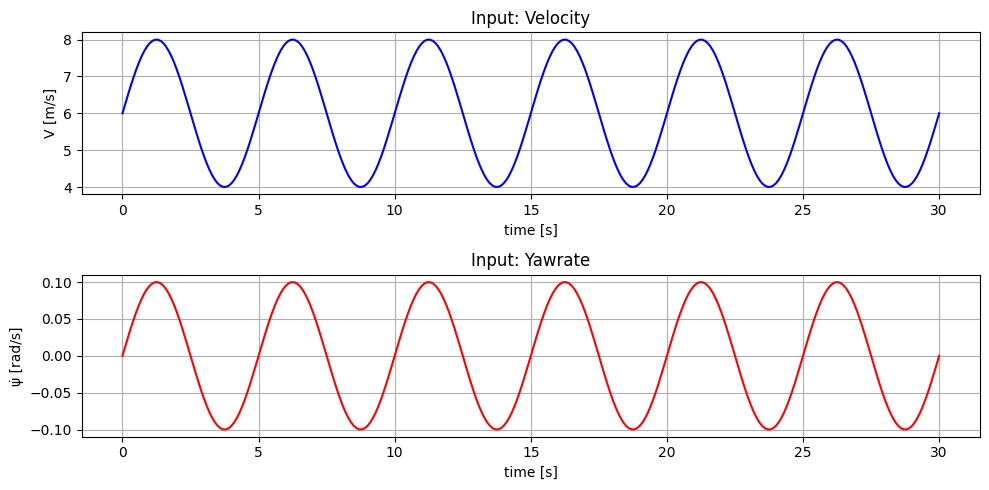

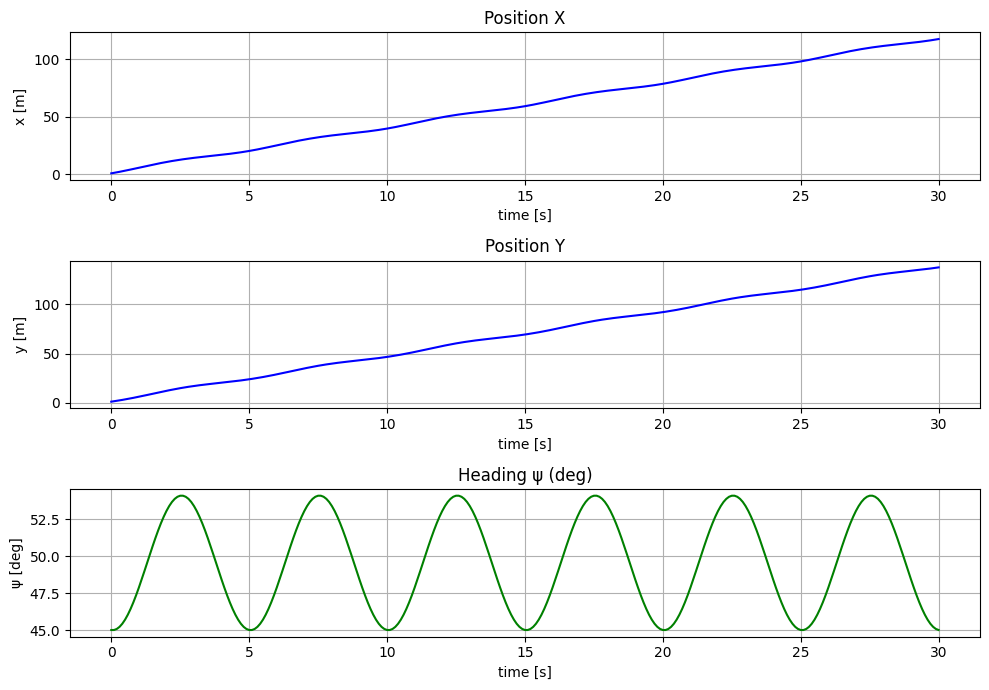

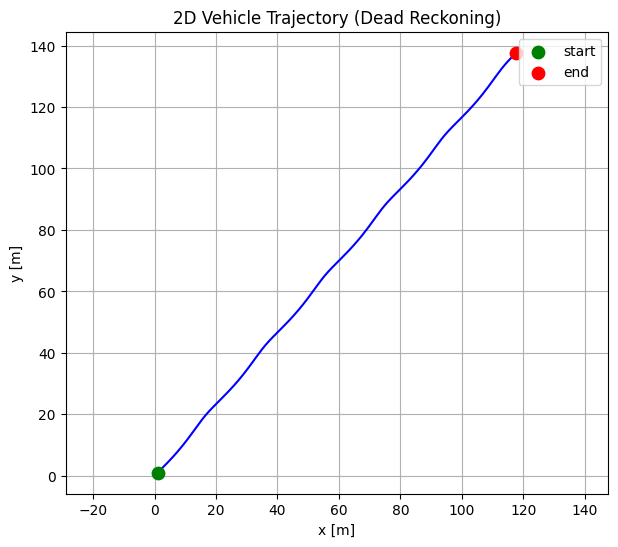

최종 위치   : x = 117.70 m,  y = 137.67 m
최종 헤딩   : ψ = 45.00°
x_history shape: (301, 3)


In [1]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import numpy as np
import matplotlib.pyplot as plt


# =========================================
# 2️⃣ 시뮬레이션 조건 설정
# =========================================
dT     = 0.1                              # 샘플링 시간 [s]
t_end  = 30                               # 종료 시간 [s]
t      = np.arange(0, t_end + dT, dT)     # [0, 0.1, ..., 30]
N      = len(t)                           # 시간 step 개수


# =========================================
# 3️⃣ 입력 데이터 생성
#    V (속도)   : 평균 6 m/s, 진폭 2, 주기 5초
#    psi_dot   : 진폭 0.1 rad/s, 주기 5초
#    
#    ※ 실제 강의 자료의 그래프와 다를 수 있음.
#       강의 자료에 명시된 입력 데이터로 교체 필요
# =========================================
V       = 6.0 + 2.0 * np.sin(2 * np.pi * t / 5)   # (N,) 속도 [m/s]
psi_dot = 0.1 * np.sin(2 * np.pi * t / 5)         # (N,) yawrate [rad/s]


# =========================================
# 4️⃣ 초기 상태 + 저장 배열 준비
#    상태: [x, y, psi]
#    초기값: (1, 1, 45°)
# =========================================
x_state = np.array([1.0,                  # x_0  : 1 m
                    1.0,                  # y_0  : 1 m
                    np.deg2rad(45)])      # psi_0: 45° → 라디안 변환
                                          # (3,) 1D 배열로 단순하게

x_history = np.zeros((N, 3))              # 각 step의 [x, y, psi]
x_history[0] = x_state                    # 초기값 저장 (k=0)


# =========================================
# 5️⃣ 비선형 Propagation 루프
#    매 step:
#      x   = x   + V · dT · cos(psi)
#      y   = y   + V · dT · sin(psi)
#      psi = psi + psi_dot · dT
# =========================================
for k in range(1, N):
    # 직전 step의 상태와 입력
    x_prev   = x_history[k-1, 0]
    y_prev   = x_history[k-1, 1]
    psi_prev = x_history[k-1, 2]
    
    V_prev       = V[k-1]
    psi_dot_prev = psi_dot[k-1]
    
    # 비선형 운동 방정식
    x_new   = x_prev   + V_prev * dT * np.cos(psi_prev)
    y_new   = y_prev   + V_prev * dT * np.sin(psi_prev)
    psi_new = psi_prev + psi_dot_prev * dT
    
    # 저장
    x_history[k] = [x_new, y_new, psi_new]


# =========================================
# 6️⃣ 결과 시각화 ① - 입력 데이터
# =========================================
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

axes[0].plot(t, V, 'b-')
axes[0].set_title('Input: Velocity')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('V [m/s]')
axes[0].grid(True)

axes[1].plot(t, psi_dot, 'r-')
axes[1].set_title('Input: Yawrate')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('ψ̇ [rad/s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 7️⃣ 결과 시각화 ② - 각 상태별 시간 그래프
# =========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 7))

axes[0].plot(t, x_history[:, 0], 'b-')
axes[0].set_title('Position X')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('x [m]')
axes[0].grid(True)

axes[1].plot(t, x_history[:, 1], 'b-')
axes[1].set_title('Position Y')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('y [m]')
axes[1].grid(True)

# 헤딩은 보기 편하게 도(degree) 단위로 표시
axes[2].plot(t, np.rad2deg(x_history[:, 2]), 'g-')
axes[2].set_title('Heading ψ (deg)')
axes[2].set_xlabel('time [s]'); axes[2].set_ylabel('ψ [deg]')
axes[2].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 8️⃣ 결과 시각화 ③ - 2D 차량 궤적
# =========================================
plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0], x_history[:, 1], 'b-', linewidth=1.5)
plt.scatter(x_history[0, 0],  x_history[0, 1],
            c='green', s=80, label='start', zorder=3)
plt.scatter(x_history[-1, 0], x_history[-1, 1],
            c='red',   s=80, label='end',   zorder=3)
plt.title('2D Vehicle Trajectory (Dead Reckoning)')
plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.show()


# =========================================
# 9️⃣ 결과 확인
# =========================================
print(f"최종 위치   : x = {x_history[-1, 0]:.2f} m,  y = {x_history[-1, 1]:.2f} m")
print(f"최종 헤딩   : ψ = {np.rad2deg(x_history[-1, 2]):.2f}°")
print(f"x_history shape: {x_history.shape}")

# 📋 Practice 6-1-2. Measurement Simulation (Bearing Sensor)

## ■ 목표
- 6-1-1에서 만든 참 위치 (x_t, y_t)에 비선형 측정 모델 적용
- Bearing 센서 측정값 (r, θ)에 가우시안 노이즈를 더해 측정값 생성
- 거리 r과 각도 θ를 동시에 측정

## ■ 측정 모델 (Bearing Sensor - 비선형!)

원점에 있는 Bearing 센서가 차량 위치를 측정:

```
        ┌  r  ┐     ┌    √(x² + y²)    ┐
   y =  │     │  =  │                  │  + noise
        └  θ  ┘     └  tan⁻¹(y / x)    ┘
```

> **비선형성**: √, tan⁻¹ 때문에 더 이상 H · x 형태로 못 씀
> 그래서 함수 형태로 표현: y = h(x)

## ■ 변수 의미

```
   r : 센서로부터 차량까지의 거리       (range)
   θ : 차량과 X축이 이루는 각도          (bearing angle)
   
   √(x² + y²)    : 피타고라스로 거리 계산
   tan⁻¹(y / x)  : x축 기준 차량 방향 각도
```

## ■ 노이즈 조건

- 거리 노이즈: σ_r = 1 m
- 각도 노이즈: σ_θ = 3° = π/60 rad
- X, Y가 아니라 **r, θ에 노이즈가 더해짐** (주의!)

## ■ 풀이 절차

### 1️⃣ 비선형 측정 함수 h(x) 정의
- 입력: 상태 [x, y, ψ]
- 출력: [r, θ] (ψ는 측정과 무관)

### 2️⃣ 노이즈 생성
- r 노이즈: N(0, σ_r²) 가우시안 (단위: m)
- θ 노이즈: N(0, σ_θ²) 가우시안 (단위: rad)

### 3️⃣ 측정값 계산
- 매 시간 step에서 h(x_true) 계산 후 노이즈 추가

### 4️⃣ 결과 시각화
- 참 r vs 측정 r (시간)
- 참 θ vs 측정 θ (시간)
- 2D 평면에서 참값 궤적 vs 측정값으로 복원한 위치

---

## ■ 한줄 정리

> 👉 "Bearing 센서로 거리와 각도를 측정. 비선형 함수 √, tan⁻¹가 들어감"
> 👉 6-2 (CV-EKF), 6-3 (DR-EKF)에서 측정 입력으로 사용됨

---

## 💡 헷갈리기 쉬운 포인트

- **각도 단위**: σ_θ는 **라디안으로 변환** 필수 (3° → π/60)
- **np.arctan2(y, x)**: 4사분면을 모두 처리. 일반 arctan보다 안전
  - arctan(y/x)는 x=0 또는 음수일 때 문제
  - arctan2(y, x)는 항상 올바른 각도 반환 (-π ~ π)
- **두 노이즈는 독립**: r과 θ에 각각 다른 난수 적용
- **측정값을 시각화로 복원**: r·cos(θ), r·sin(θ)로 (x, y) 위치 복원 가능

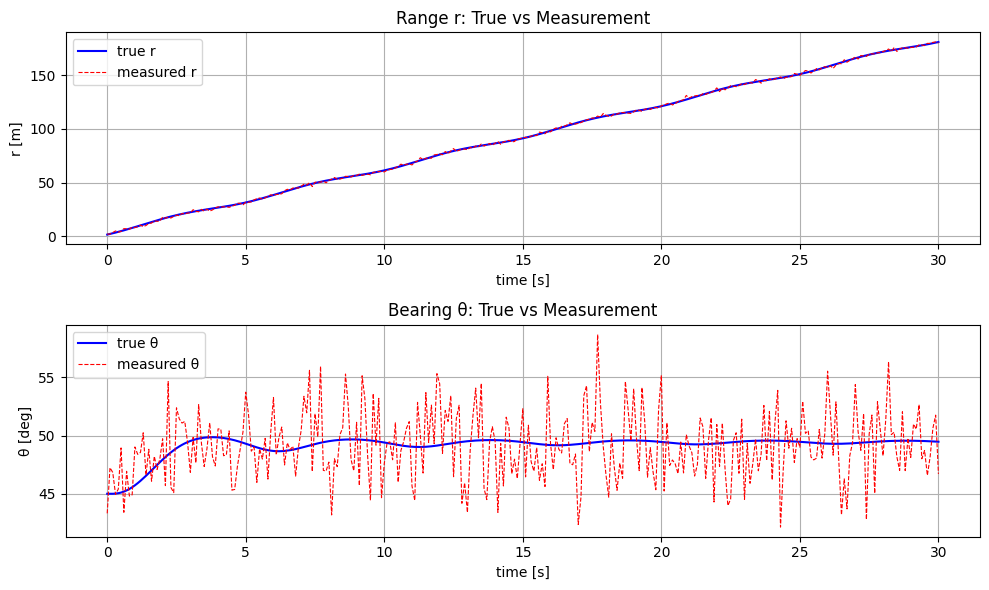

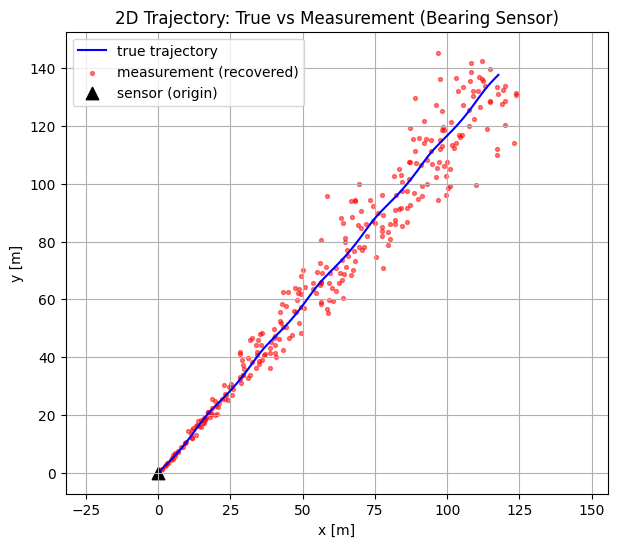

r 노이즈 평균   : -0.0083     (이론: 0)
r 노이즈 표준편차: 0.9821      (이론: 1.0)
θ 노이즈 평균   : -0.0576°    (이론: 0°)
θ 노이즈 표준편차: 2.8792°     (이론: 3.00°)
y_history shape: (301, 2)


In [2]:
# =========================================
# 1️⃣ 노이즈 재현성을 위한 seed 설정
# =========================================
np.random.seed(42)


# =========================================
# 2️⃣ 비선형 측정 함수 h(x) 정의
#    입력: state = [x, y, psi]
#    출력: [r, theta]
# =========================================
def h(state):
    """
    Bearing sensor measurement model
    
    Parameters
    ----------
    state : (3,) [x, y, psi]
    
    Returns
    -------
    measurement : (2,) [r, theta]
    """
    x   = state[0]
    y   = state[1]
    
    r     = np.sqrt(x**2 + y**2)          # 거리
    theta = np.arctan2(y, x)              # 각도 (4사분면 안전)
    
    return np.array([r, theta])


# =========================================
# 3️⃣ 측정 노이즈 표준편차 설정
#    r은 미터, theta는 라디안 단위로 통일
# =========================================
sigma_r     = 1.0                         # 거리 노이즈 표준편차 [m]
sigma_theta = np.deg2rad(3)               # 각도 노이즈 표준편차 [rad]
                                          # 3° → 라디안 변환


# =========================================
# 4️⃣ 노이즈 생성
#    r과 theta 각각 독립적으로 N(0, sigma²)
# =========================================
noise_r     = np.random.normal(0, sigma_r,     N)   # (N,) 거리 노이즈
noise_theta = np.random.normal(0, sigma_theta, N)   # (N,) 각도 노이즈


# =========================================
# 5️⃣ 측정값 계산
#    매 시간 step:
#      [r_true, theta_true] = h(x_true)
#      [r_meas, theta_meas] = [r_true + noise, theta_true + noise]
# =========================================
y_history       = np.zeros((N, 2))        # (N, 2) 측정값 [r, theta]
y_history_true  = np.zeros((N, 2))        # (N, 2) 참 측정값 (노이즈 없음, 비교용)

for k in range(N):
    # 참 측정값 (노이즈 없음)
    z_true = h(x_history[k])              # (2,) [r_true, theta_true]
    y_history_true[k] = z_true
    
    # 노이즈 추가한 측정값
    y_history[k, 0] = z_true[0] + noise_r[k]      # 측정 r
    y_history[k, 1] = z_true[1] + noise_theta[k]  # 측정 theta


# =========================================
# 6️⃣ 결과 시각화 ① - 시간에 따른 r, θ 비교
# =========================================
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# 거리 r 비교
axes[0].plot(t, y_history_true[:, 0], 'b-',  label='true r', linewidth=1.5)
axes[0].plot(t, y_history[:, 0],      'r--', label='measured r', linewidth=0.8)
axes[0].set_title('Range r: True vs Measurement')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('r [m]')
axes[0].legend(); axes[0].grid(True)

# 각도 θ 비교 (deg 단위로 보기 편하게)
axes[1].plot(t, np.rad2deg(y_history_true[:, 1]), 'b-',
             label='true θ', linewidth=1.5)
axes[1].plot(t, np.rad2deg(y_history[:, 1]),      'r--',
             label='measured θ', linewidth=0.8)
axes[1].set_title('Bearing θ: True vs Measurement')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('θ [deg]')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 7️⃣ 결과 시각화 ② - 2D 평면 궤적 비교
#    측정값 (r, θ)를 (x, y)로 변환해서 plot:
#       x_meas = r · cos(θ)
#       y_meas = r · sin(θ)
# =========================================
x_meas = y_history[:, 0] * np.cos(y_history[:, 1])
y_meas = y_history[:, 0] * np.sin(y_history[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0], x_history[:, 1],
         'b-',  linewidth=1.5, label='true trajectory')
plt.scatter(x_meas, y_meas,
            c='red', s=8, alpha=0.5, label='measurement (recovered)')
plt.scatter(0, 0, c='black', s=80, marker='^', label='sensor (origin)')

plt.title('2D Trajectory: True vs Measurement (Bearing Sensor)')
plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.show()


# =========================================
# 8️⃣ 노이즈 통계 확인 (검증용)
# =========================================
print(f"r 노이즈 평균   : {np.mean(noise_r):.4f}     (이론: 0)")
print(f"r 노이즈 표준편차: {np.std(noise_r):.4f}      (이론: {sigma_r})")
print(f"θ 노이즈 평균   : {np.rad2deg(np.mean(noise_theta)):.4f}°    (이론: 0°)")
print(f"θ 노이즈 표준편차: {np.rad2deg(np.std(noise_theta)):.4f}°     (이론: {np.rad2deg(sigma_theta):.2f}°)")
print(f"y_history shape: {y_history.shape}")

# 📋 Practice 6-2. EKF with CV (Constant Velocity) Model

## ■ 목표
- **시스템 모델은 선형 (CV)**, **측정 모델은 비선형 (Bearing)** 인 상황에서 EKF 적용
- 측정 모델의 비선형성 때문에 일반 KF는 못 쓰고 **EKF 필요**
- 측정 자코비안 H를 매 step마다 계산해서 update에 사용

## ■ 왜 EKF가 필요한가?

```
시스템: x_{t+1} = F · x_t        (선형 OK!)
측정:   y_t = h(x_t)             (비선형!  H · x로 못 씀)
                                  → EKF로 해결
```

> **핵심**: 시스템이 선형이어도 측정 하나가 비선형이면 EKF 사용

## ■ CV Process Model (선형, Practice 5-2와 동일)

```
x_t = [x, y, v_x, v_y]ᵀ  (4차원)
```

```
        ┌ 1  0  dT  0 ┐
        │ 0  1  0   dT│
   F =  │ 0  0  1   0 │       (4 × 4)
        └ 0  0  0   1 ┘
```

## ■ Measurement Model (비선형!)

```
        ┌  r  ┐     ┌    √(x² + y²)    ┐
   y =  │     │  =  │                  │   = h(x)
        └  θ  ┘     └  tan⁻¹(y / x)    ┘
```

## ■ 측정 자코비안 H 유도 (★ 핵심)

H는 h(x)를 각 상태 변수로 편미분한 행렬:

```
        ┌ ∂r/∂x       ∂r/∂y       ∂r/∂vx    ∂r/∂vy   ┐
   H =  │                                              │
        └ ∂θ/∂x       ∂θ/∂y       ∂θ/∂vx    ∂θ/∂vy   ┘
```

### 1️⃣ ∂r/∂x, ∂r/∂y (r = √(x²+y²))

```
∂r/∂x = x / √(x² + y²) = x / r
∂r/∂y = y / √(x² + y²) = y / r
```

### 2️⃣ ∂θ/∂x, ∂θ/∂y (θ = tan⁻¹(y/x))

```
∂θ/∂x = -y / (x² + y²) = -y / r²
∂θ/∂y =  x / (x² + y²) =  x / r²
```

### 3️⃣ vx, vy 미분: 0 (h에 vx, vy 없음)

### 4️⃣ 최종 H 행렬

```
        ┌  x/r        y/r        0    0  ┐
   H =  │                                 │     (2 × 4)
        └ -y/r²       x/r²       0    0  ┘
```

> **중요**: H는 매 step마다 **현재 추정값 x̂⁻에서 계산**됨
> → "현재 위치에서의 선형 근사"

## ■ EKF 알고리즘

```
■ Prediction (시스템이 선형이라 KF와 동일)
   x̂⁻ = F · x̂
   P⁻  = F · P · Fᵀ + Q

■ Update (측정 자코비안 H 사용)
   H_t = ∂h/∂x | _{x̂⁻}                ← 매 step 계산!
   K   = P⁻ · H_tᵀ · (H_t · P⁻ · H_tᵀ + R)⁻¹
   x̂⁺ = x̂⁻ + K · (y − h(x̂⁻))          ← 비선형 h() 직접 사용
   P⁺  = (I − K · H_t) · P⁻
```

## ■ Q, R, 초기 조건

- Q: CV 모델 process noise (가속도 불확실성 기반, Practice 5-2와 동일 형태)
- R: diag(σ_r², σ_θ²) (거리 + 각도 노이즈)
- x_0: [0, 0, 0, 0]ᵀ
- P_0: diag(10000, 10000, 10000, 10000)

## ■ 풀이 절차

### 1️⃣ CV 모델 행렬 정의 (F)
### 2️⃣ 측정 함수 h() 정의 (이미 6-1-2에 있음)
### 3️⃣ 측정 자코비안 함수 H_jacobian() 정의
### 4️⃣ Q, R 행렬 + 초기 조건 설정
### 5️⃣ EKF 루프 (Prediction → Update)
### 6️⃣ 결과 시각화 (Practice 6-2-1)
### 7️⃣ RMSE 계산 (Practice 6-2-2)
### 8️⃣ 공분산 P plot (Practice 6-2-3)

---

## ■ 한줄 정리

> 👉 "측정이 비선형인 경우, 매 step마다 자코비안 H를 다시 계산해서 KF처럼 사용"
> 👉 H는 고정 X, 매 step마다 갱신 O

---

## 💡 헷갈리기 쉬운 포인트

- **H가 매 step마다 다름**: 일반 KF에서는 H 고정, EKF는 매번 새로 계산
- **혼동 주의**: innovation 계산 시 `y - h(x̂)` (비선형), 게인 계산 시 `H` (자코비안)
- **r²이 분모**: x, y가 0에 가까우면 division by zero 위험 (이번 문제는 OK)
- **theta wrap**: innovation의 θ가 ±π 넘으면 보정 필요 (안전 처리)

In [3]:
# # =========================================
# # 1️⃣ CV 모델 시스템 행렬 정의
# # =========================================
# F_cv = np.array([[1.0, 0.0, dT,  0.0],
#                  [0.0, 1.0, 0.0, dT ],
#                  [0.0, 0.0, 1.0, 0.0],
#                  [0.0, 0.0, 0.0, 1.0]])  # (4, 4)


# # =========================================
# # 2️⃣ 측정 함수 h(x) 정의 (CV 버전)
# #    상태: [x, y, vx, vy] (4차원)
# #    출력: [r, theta]
# # =========================================
# def h_cv(state):
#     """
#     Bearing measurement model for CV state [x, y, vx, vy]
#     """
#     x = state[0]
#     y = state[1]
    
#     r     = np.sqrt(x**2 + y**2)
#     theta = np.arctan2(y, x)
    
#     return np.array([r, theta])


# # =========================================
# # 3️⃣ 측정 자코비안 H 계산 함수
# #    H = ∂h/∂x | _{현재 추정 위치}
# #    상태: [x, y, vx, vy]
# # =========================================
# def H_jacobian_cv(state):
#     """
#     Measurement Jacobian for Bearing sensor (CV model)
    
#     H = [[ x/r,    y/r,    0, 0],
#          [-y/r²,   x/r²,   0, 0]]
#     """
#     x = state[0]
#     y = state[1]
    
#     r2 = x**2 + y**2                      # r² (분모)
#     r  = np.sqrt(r2)                      # r
    
#     H = np.array([[ x / r,    y / r,    0.0, 0.0],
#                   [-y / r2,   x / r2,   0.0, 0.0]])
#     return H                              # (2, 4)


# # =========================================
# # 4️⃣ Angle wrap 함수 (각도 차이를 ±π 안으로 보정)
# #    innovation의 theta 부분에 적용
# # =========================================
# def wrap_angle(angle):
#     """각도를 -π ~ π 범위로 wrap"""
#     return (angle + np.pi) % (2 * np.pi) - np.pi


# # =========================================
# # 5️⃣ Q 행렬 설계 (Practice 5-2와 동일 방식)
# #    가속도 불확실성 σ_a 기반
# # =========================================
# sigma_ax = 1.0                            # 가속도 X 불확실성 [m/s²]
# sigma_ay = 1.0                            # 가속도 Y 불확실성 [m/s²]

# Q_cv = np.array([
#     [dT**4/4 * sigma_ax**2,  0.0,                    dT**3/2 * sigma_ax**2, 0.0                  ],
#     [0.0,                    dT**4/4 * sigma_ay**2,  0.0,                   dT**3/2 * sigma_ay**2],
#     [dT**3/2 * sigma_ax**2,  0.0,                    dT**2   * sigma_ax**2, 0.0                  ],
#     [0.0,                    dT**3/2 * sigma_ay**2,  0.0,                   dT**2   * sigma_ay**2]
# ])                                        # (4, 4)


# # =========================================
# # 6️⃣ R 행렬 설정 (측정 노이즈 공분산)
# #    r과 theta 독립적으로 가정
# # =========================================
# R_cv = np.array([[sigma_r**2,     0.0           ],
#                  [0.0,            sigma_theta**2]])  # (2, 2)


# # =========================================
# # 7️⃣ 초기 조건 + 저장 배열 준비
# # =========================================
# x_hat = np.array([[0.0],                  # 초기 추정 [x, y, vx, vy]
#                   [0.0],
#                   [0.0],
#                   [0.0]])                 # (4, 1)

# P = np.diag([10000.0, 10000.0,
#              10000.0, 10000.0])           # (4, 4)

# I_4 = np.eye(4)                           # 4×4 단위행렬

# x_hat_cv_ekf   = np.zeros((N, 4))         # 추정 상태
# P_prior_cv_ekf = np.zeros((N, 4, 4))
# P_post_cv_ekf  = np.zeros((N, 4, 4))


# # =========================================
# # 8️⃣ EKF 루프
# # =========================================
# for k in range(N):
#     # ---------- Prediction ----------
#     x_hat = F_cv @ x_hat                  # (4, 1) 선형 시스템이므로 F·x
#     P     = F_cv @ P @ F_cv.T + Q_cv      # (4, 4)
#     P_prior_cv_ekf[k] = P
    
#     # ---------- Update ----------
#     # 1) 측정값 (r, theta) 가져오기
#     y_k = y_history[k].reshape(2, 1)      # (2, 1)
    
#     # 2) 자코비안 H 계산 (현재 추정값에서)
#     H = H_jacobian_cv(x_hat.flatten())    # (2, 4)
    
#     # 3) 예측 측정값 (비선형 h() 사용)
#     z_pred = h_cv(x_hat.flatten()).reshape(2, 1)   # (2, 1)
    
#     # 4) Innovation (각도는 wrap 처리)
#     innovation = y_k - z_pred             # (2, 1)
#     innovation[1, 0] = wrap_angle(innovation[1, 0])
    
#     # 5) 칼만 게인
#     S = H @ P @ H.T + R_cv                # (2, 2)
#     K = P @ H.T @ np.linalg.inv(S)        # (4, 2)
    
#     # 6) 상태 + 공분산 업데이트
#     x_hat = x_hat + K @ innovation        # (4, 1)
#     P     = (I_4 - K @ H) @ P             # (4, 4)
#     P_post_cv_ekf[k] = P
    
#     # 저장
#     x_hat_cv_ekf[k] = x_hat.flatten()


# # =========================================
# # 9️⃣ Practice 6-2-1: 추정 상태 + 오차 plot
# #    참값과 비교를 위해 vx, vy를 V·cos(ψ), V·sin(ψ)로 계산
# # =========================================
# # 참 vx, vy 계산
# vx_true = V * np.cos(x_history[:, 2])     # V · cos(ψ)
# vy_true = V * np.sin(x_history[:, 2])     # V · sin(ψ)

# # 참 상태 (x, y, vx, vy)
# true_states_cv = np.column_stack([x_history[:, 0],   # x
#                                    x_history[:, 1],   # y
#                                    vx_true,           # vx
#                                    vy_true])          # vy

# fig, axes = plt.subplots(4, 2, figsize=(12, 10))
# labels = ['Position X', 'Position Y', 'Velocity Vx', 'Velocity Vy']
# units  = ['m', 'm', 'm/s', 'm/s']

# for i in range(4):
#     # 좌측: 추정 vs 참값
#     axes[i, 0].plot(t, true_states_cv[:, i], 'b-',  label='true', linewidth=1.5)
#     axes[i, 0].plot(t, x_hat_cv_ekf[:, i],   'r--', label='EKF estimate', linewidth=1.0)
#     axes[i, 0].set_title(f'Estimate {labels[i]}')
#     axes[i, 0].set_ylabel(f'[{units[i]}]')
#     axes[i, 0].legend(); axes[i, 0].grid(True)
    
#     # 우측: 오차
#     error = true_states_cv[:, i] - x_hat_cv_ekf[:, i]
#     axes[i, 1].plot(t, error, 'g-')
#     axes[i, 1].axhline(0, color='k', linewidth=0.5)
#     axes[i, 1].set_title(f'Error {labels[i]}')
#     axes[i, 1].set_ylabel(f'error [{units[i]}]')
#     axes[i, 1].grid(True)

# axes[3, 0].set_xlabel('time [s]')
# axes[3, 1].set_xlabel('time [s]')

# plt.suptitle('Practice 6-2-1: CV-EKF Estimation', fontsize=14)
# plt.tight_layout()
# plt.show()


# # =========================================
# # 🔟 Practice 6-2-2: RMSE 계산
# # =========================================
# rmse_cv_ekf = np.zeros(4)
# for i in range(4):
#     rmse_cv_ekf[i] = np.sqrt(np.mean((true_states_cv[:, i] - x_hat_cv_ekf[:, i])**2))

# print("=" * 50)
# print("Practice 6-2-2: CV-EKF RMSE")
# print("=" * 50)
# for i in range(4):
#     print(f"RMSE {labels[i]:14s}: {rmse_cv_ekf[i]:.4f} {units[i]}")
# print("=" * 50)


# # =========================================
# # 1️⃣1️⃣ Practice 6-2-3: 공분산 P plot
# #    P 행렬 4×4 = 16개 원소
# # =========================================
# fig, axes = plt.subplots(4, 4, figsize=(14, 10))

# for i in range(4):
#     for j in range(4):
#         axes[i, j].plot(t, P_prior_cv_ekf[:, i, j], 'r-',  linewidth=0.8)
#         axes[i, j].plot(t, P_post_cv_ekf[:, i, j],  'b--', linewidth=0.8)
#         axes[i, j].set_title(f'P[{i},{j}]', fontsize=9)
#         axes[i, j].grid(True)
#         axes[i, j].tick_params(labelsize=6)

# axes[0, 0].plot([], [], 'r-',  label='P_prior')
# axes[0, 0].plot([], [], 'b--', label='P_posterior')
# axes[0, 0].legend(fontsize=7, loc='upper right')

# plt.suptitle('Practice 6-2-3: Covariance P (CV-EKF)', fontsize=14)
# plt.tight_layout()
# plt.show()

# 새롭게 구성한 6-2


Practice 6-2 CV-EKF Q Tuning Start
Practice 6-2 CV-EKF Q Tuning Finished
Practice 6-2 CV-EKF Best Q Result
Best sigma_ax       = 0.1000 m/s^2
Best sigma_ay       = 0.1000 m/s^2
Best Position RMSE  = 0.863463 m
Practice 6-2-2 CV-EKF RMSE with Best Q
RMSE Position X    : 0.902905 m
RMSE Position Y    : 0.822131 m
RMSE Velocity Vx   : 1.111713 m/s
RMSE Velocity Vy   : 1.217179 m/s
Position RMSE 기준값 : 0.863463 m


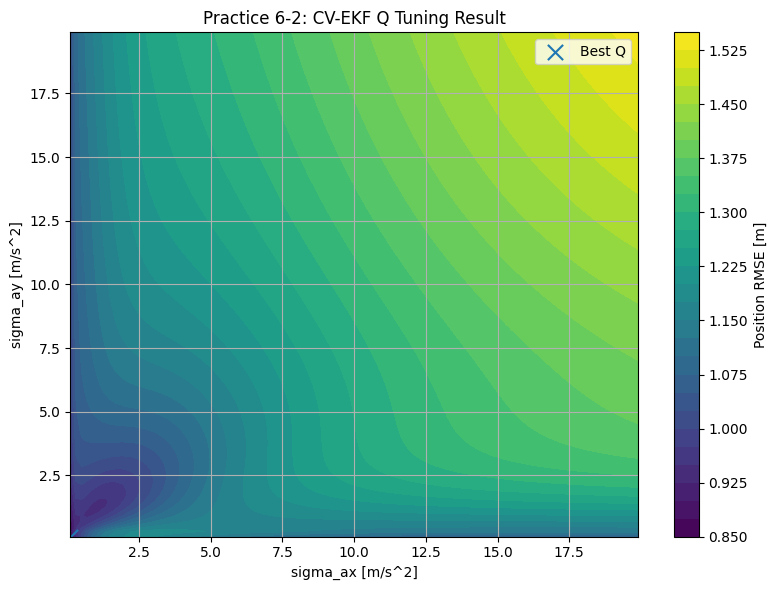

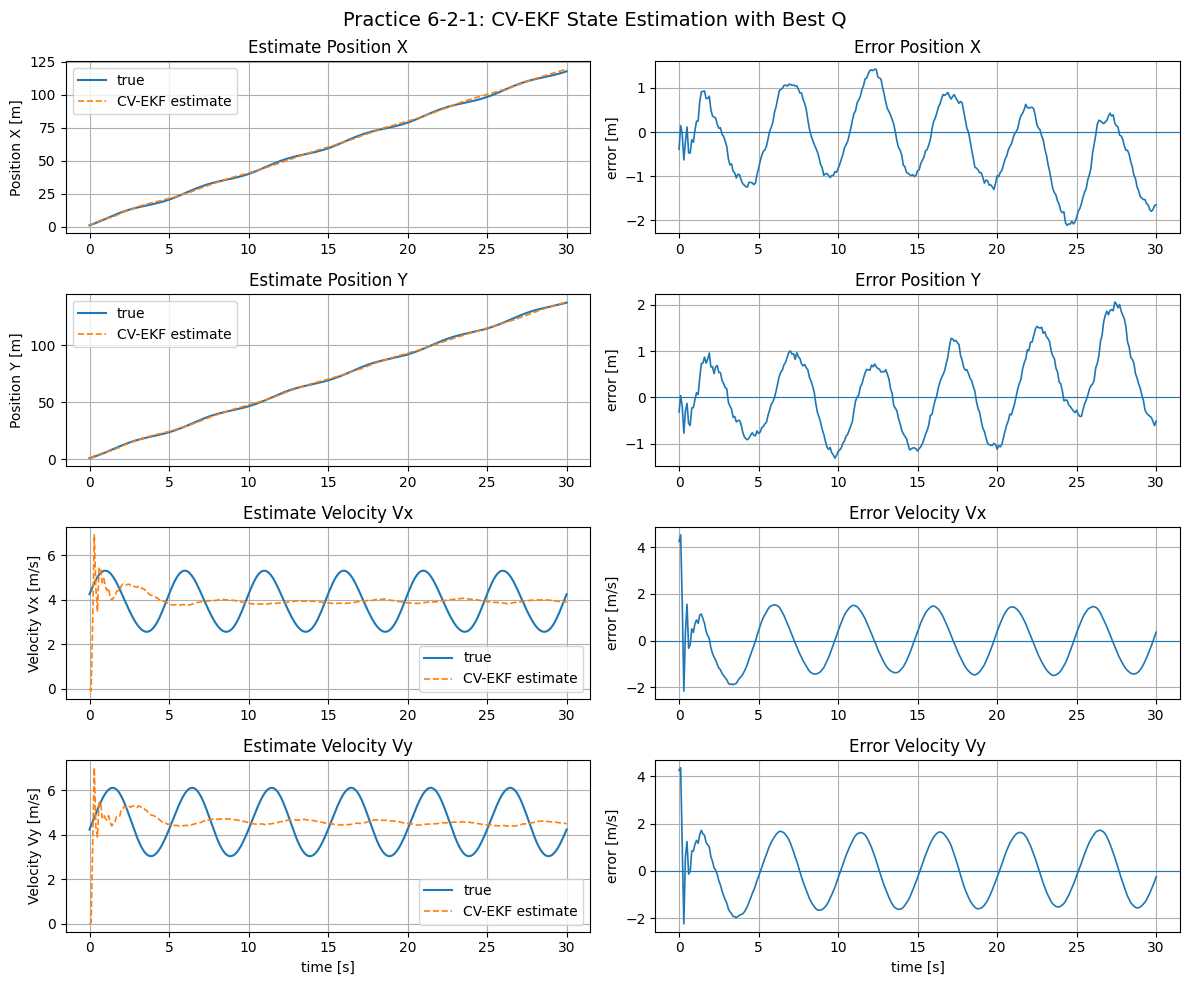

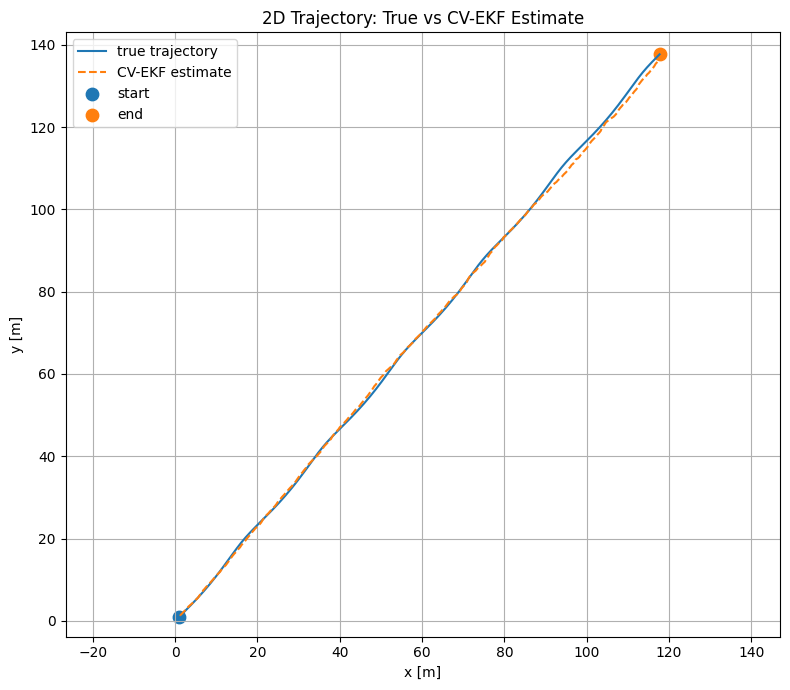

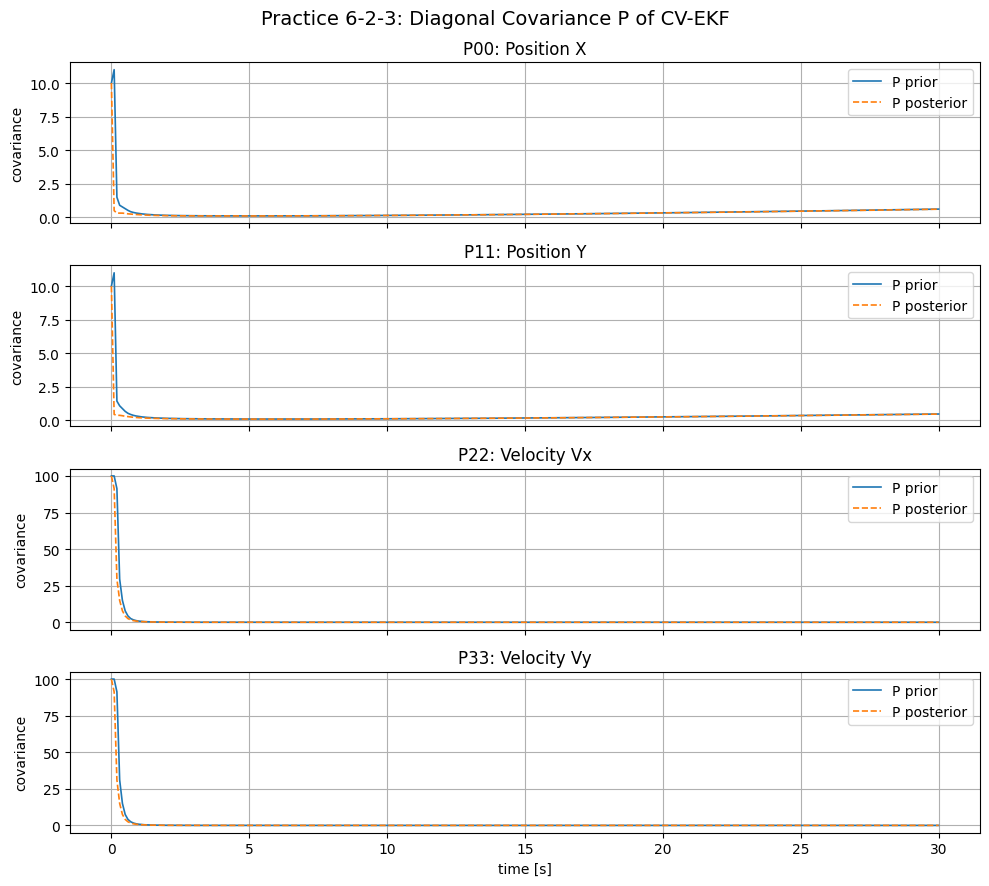

In [4]:
# ============================================================
# Practice 6-2: CV-EKF with Best Q Tuning
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1️⃣ CV Model 시스템 행렬 정의
#    State: [x, y, vx, vy]^T
# ============================================================

F_cv = np.array([
    [1.0, 0.0, dT,  0.0],
    [0.0, 1.0, 0.0, dT ],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])  # (4, 4)

I_4 = np.eye(4)


# ============================================================
# 2️⃣ Bearing Sensor Measurement Model 정의
#    h(x) = [r, theta]^T
# ============================================================

def h_cv(state):
    """
    CV-EKF measurement function

    input:
        state = [x, y, vx, vy]

    output:
        z = [range, bearing angle]
    """
    x = state[0]
    y = state[1]

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    return np.array([r, theta])


# ============================================================
# 3️⃣ Measurement Jacobian 정의
#    H = ∂h/∂x
# ============================================================

def H_jacobian_cv(state):
    """
    Measurement Jacobian for CV-EKF

    state = [x, y, vx, vy]

    H = [[ x/r,    y/r,    0, 0],
         [-y/r²,   x/r²,   0, 0]]
    """
    x = state[0]
    y = state[1]

    r2 = x**2 + y**2
    eps = 1e-8

    # 원점 근처 singularity 방지
    if r2 < eps:
        r2 = eps

    r = np.sqrt(r2)

    H = np.array([
        [ x / r,    y / r,    0.0, 0.0],
        [-y / r2,   x / r2,   0.0, 0.0]
    ])  # (2, 4)

    return H


# ============================================================
# 4️⃣ Angle Wrap 함수
#    angle error를 -pi ~ pi 범위로 변환
# ============================================================

def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


# ============================================================
# 5️⃣ Q Matrix 생성 함수
#    sigma_ax, sigma_ay 기준으로 CV process noise covariance 구성
# ============================================================

def make_Q_cv(sigma_ax, sigma_ay, dT):
    """
    CV Model에서 모르는 가속도 입력을 process noise로 흡수한 Q

    sigma_ax: x 방향 가속도 불확실성 [m/s^2]
    sigma_ay: y 방향 가속도 불확실성 [m/s^2]
    """

    Q_cv = np.array([
        [dT**4/4 * sigma_ax**2, 0.0,                    dT**3/2 * sigma_ax**2, 0.0],
        [0.0,                   dT**4/4 * sigma_ay**2, 0.0,                    dT**3/2 * sigma_ay**2],
        [dT**3/2 * sigma_ax**2, 0.0,                    dT**2   * sigma_ax**2, 0.0],
        [0.0,                   dT**3/2 * sigma_ay**2, 0.0,                    dT**2   * sigma_ay**2]
    ])  # (4, 4)

    return Q_cv


# ============================================================
# 6️⃣ R Matrix 설정
#    Measurement noise covariance
# ============================================================

R_cv = np.array([
    [sigma_r**2,      0.0],
    [0.0,             sigma_theta**2]
])  # (2, 2)


# ============================================================
# 7️⃣ True State for CV 비교용 생성
#    true state = [x, y, vx, vy]
# ============================================================

vx_true = V * np.cos(x_history[:, 2])
vy_true = V * np.sin(x_history[:, 2])

true_states_cv = np.column_stack([
    x_history[:, 0],   # true x
    x_history[:, 1],   # true y
    vx_true,           # true vx
    vy_true            # true vy
])  # (N, 4)


# ============================================================
# 8️⃣ CV-EKF 실행 함수
#    입력: sigma_ax, sigma_ay
#    출력: 추정 상태, P, RMSE
# ============================================================

def run_cv_ekf(sigma_ax, sigma_ay, return_history=True):
    """
    CV-EKF 실행 함수

    핵심:
    - 초기 위치는 첫 번째 range-bearing measurement를 Cartesian 좌표로 변환하여 설정
    - 초기값 [0,0,0,0] 사용 금지
      → bearing measurement model의 Jacobian singularity 방지
    """

    # --------------------------------------------------------
    # Q 생성
    # --------------------------------------------------------
    Q_cv = make_Q_cv(sigma_ax, sigma_ay, dT)

    # --------------------------------------------------------
    # 초기 상태 설정
    # 첫 번째 측정값 [r0, theta0]를 Cartesian으로 변환
    # --------------------------------------------------------
    r0_meas = y_history[0, 0]
    theta0_meas = y_history[0, 1]

    x0_meas = r0_meas * np.cos(theta0_meas)
    y0_meas = r0_meas * np.sin(theta0_meas)

    x_hat = np.array([
        [x0_meas],
        [y0_meas],
        [0.0],
        [0.0]
    ])  # (4, 1)

    # --------------------------------------------------------
    # 초기 공분산 설정
    # 위치는 첫 측정값으로 초기화했으므로 너무 크지 않게 설정
    # 속도는 모르는 값이므로 크게 설정
    # --------------------------------------------------------
    P = np.diag([
        10.0,
        10.0,
        100.0,
        100.0
    ])  # (4, 4)

    # --------------------------------------------------------
    # 저장 배열
    # --------------------------------------------------------
    x_hat_history = np.zeros((N, 4))
    P_prior_history = np.zeros((N, 4, 4))
    P_post_history = np.zeros((N, 4, 4))

    x_hat_history[0] = x_hat.flatten()
    P_prior_history[0] = P
    P_post_history[0] = P

    # ========================================================
    # EKF Loop
    # ========================================================
    for k in range(1, N):

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------
        x_pred = F_cv @ x_hat
        P_pred = F_cv @ P @ F_cv.T + Q_cv

        P_prior_history[k] = P_pred

        # ----------------------------------------------------
        # Measurement Update
        # ----------------------------------------------------
        y_k = y_history[k].reshape(2, 1)

        z_pred = h_cv(x_pred.flatten()).reshape(2, 1)
        H_k = H_jacobian_cv(x_pred.flatten())

        innovation = y_k - z_pred
        innovation[1, 0] = wrap_angle(innovation[1, 0])

        S = H_k @ P_pred @ H_k.T + R_cv

        # K = P H^T S^{-1}
        # inv(S) 대신 solve 사용
        K = P_pred @ H_k.T @ np.linalg.solve(S, np.eye(2))

        x_hat = x_pred + K @ innovation

        # Joseph form covariance update
        # 수치적으로 더 안정적
        P = (I_4 - K @ H_k) @ P_pred @ (I_4 - K @ H_k).T + K @ R_cv @ K.T

        x_hat_history[k] = x_hat.flatten()
        P_post_history[k] = P

    # ========================================================
    # RMSE 계산
    # ========================================================
    rmse_state = np.zeros(4)

    for i in range(4):
        rmse_state[i] = np.sqrt(
            np.mean((true_states_cv[:, i] - x_hat_history[:, i])**2)
        )

    rmse_x = rmse_state[0]
    rmse_y = rmse_state[1]

    rmse_position = np.sqrt((rmse_x**2 + rmse_y**2) / 2)

    if return_history:
        return x_hat_history, P_prior_history, P_post_history, rmse_state, rmse_position
    else:
        return rmse_position


# ============================================================
# 9️⃣ sigma_ax, sigma_ay Grid Search
#    Best Q 탐색
# ============================================================

sigma_ax_list = np.arange(0.1, 20.1, 0.2)
sigma_ay_list = np.arange(0.1, 20.1, 0.2)

RMSE_grid = np.zeros((len(sigma_ax_list), len(sigma_ay_list)))

print("=" * 60)
print("Practice 6-2 CV-EKF Q Tuning Start")
print("=" * 60)

for i, sigma_ax in enumerate(sigma_ax_list):
    for j, sigma_ay in enumerate(sigma_ay_list):

        rmse_position = run_cv_ekf(
            sigma_ax=sigma_ax,
            sigma_ay=sigma_ay,
            return_history=False
        )

        RMSE_grid[i, j] = rmse_position

print("=" * 60)
print("Practice 6-2 CV-EKF Q Tuning Finished")
print("=" * 60)


# ============================================================
# 🔟 최적 Q 탐색 결과
# ============================================================

min_idx = np.argmin(RMSE_grid)
best_i, best_j = np.unravel_index(min_idx, RMSE_grid.shape)

best_sigma_ax = sigma_ax_list[best_i]
best_sigma_ay = sigma_ay_list[best_j]
best_position_rmse = RMSE_grid[best_i, best_j]

print("=" * 60)
print("Practice 6-2 CV-EKF Best Q Result")
print("=" * 60)
print(f"Best sigma_ax       = {best_sigma_ax:.4f} m/s^2")
print(f"Best sigma_ay       = {best_sigma_ay:.4f} m/s^2")
print(f"Best Position RMSE  = {best_position_rmse:.6f} m")
print("=" * 60)


# ============================================================
# 1️⃣1️⃣ 최적 Q로 CV-EKF 재실행
# ============================================================

x_hat_cv_ekf, P_prior_cv_ekf, P_post_cv_ekf, rmse_cv_ekf, rmse_pos_cv_ekf = run_cv_ekf(
    sigma_ax=best_sigma_ax,
    sigma_ay=best_sigma_ay,
    return_history=True
)

labels = ["Position X", "Position Y", "Velocity Vx", "Velocity Vy"]
units = ["m", "m", "m/s", "m/s"]

print("=" * 60)
print("Practice 6-2-2 CV-EKF RMSE with Best Q")
print("=" * 60)

for i in range(4):
    print(f"RMSE {labels[i]:14s}: {rmse_cv_ekf[i]:.6f} {units[i]}")

print(f"Position RMSE 기준값 : {rmse_pos_cv_ekf:.6f} m")
print("=" * 60)


# ============================================================
# 1️⃣2️⃣ Q Tuning 결과 시각화
# ============================================================

SIGMA_AX, SIGMA_AY = np.meshgrid(
    sigma_ax_list,
    sigma_ay_list,
    indexing="ij"
)

plt.figure(figsize=(8, 6))
contour = plt.contourf(SIGMA_AX, SIGMA_AY, RMSE_grid, levels=30)
plt.colorbar(contour, label="Position RMSE [m]")

plt.scatter(
    best_sigma_ax,
    best_sigma_ay,
    marker="x",
    s=120,
    label="Best Q"
)

plt.title("Practice 6-2: CV-EKF Q Tuning Result")
plt.xlabel("sigma_ax [m/s^2]")
plt.ylabel("sigma_ay [m/s^2]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣3️⃣ Practice 6-2-1
#      추정 상태와 실제값 비교 Plot
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(12, 10))

for i in range(4):

    # --------------------------------------------------------
    # Estimate vs True
    # --------------------------------------------------------
    axes[i, 0].plot(
        t,
        true_states_cv[:, i],
        label="true",
        linewidth=1.5
    )

    axes[i, 0].plot(
        t,
        x_hat_cv_ekf[:, i],
        linestyle="--",
        label="CV-EKF estimate",
        linewidth=1.2
    )

    axes[i, 0].set_title(f"Estimate {labels[i]}")
    axes[i, 0].set_ylabel(f"{labels[i]} [{units[i]}]")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # --------------------------------------------------------
    # Estimation Error
    # --------------------------------------------------------
    error_i = true_states_cv[:, i] - x_hat_cv_ekf[:, i]

    axes[i, 1].plot(
        t,
        error_i,
        linewidth=1.2
    )

    axes[i, 1].axhline(0.0, linewidth=0.8)
    axes[i, 1].set_title(f"Error {labels[i]}")
    axes[i, 1].set_ylabel(f"error [{units[i]}]")
    axes[i, 1].grid(True)

axes[3, 0].set_xlabel("time [s]")
axes[3, 1].set_xlabel("time [s]")

plt.suptitle("Practice 6-2-1: CV-EKF State Estimation with Best Q", fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣4️⃣ Practice 6-2-1
#      2D Trajectory 비교 Plot
# ============================================================

plt.figure(figsize=(8, 7))

plt.plot(
    true_states_cv[:, 0],
    true_states_cv[:, 1],
    label="true trajectory",
    linewidth=1.5
)

plt.plot(
    x_hat_cv_ekf[:, 0],
    x_hat_cv_ekf[:, 1],
    linestyle="--",
    label="CV-EKF estimate",
    linewidth=1.5
)

plt.scatter(
    true_states_cv[0, 0],
    true_states_cv[0, 1],
    s=80,
    label="start"
)

plt.scatter(
    true_states_cv[-1, 0],
    true_states_cv[-1, 1],
    s=80,
    label="end"
)

plt.title("2D Trajectory: True vs CV-EKF Estimate")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 1️⃣5️⃣ Practice 6-2-3
#      P00, P11, P22, P33 시간 변화 Plot
# ============================================================

P_diag_labels = ["P00: Position X", "P11: Position Y", "P22: Velocity Vx", "P33: Velocity Vy"]
P_diag_indices = [0, 1, 2, 3]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

for ax, idx, label in zip(axes, P_diag_indices, P_diag_labels):

    ax.plot(
        t,
        P_prior_cv_ekf[:, idx, idx],
        label="P prior",
        linewidth=1.2
    )

    ax.plot(
        t,
        P_post_cv_ekf[:, idx, idx],
        linestyle="--",
        label="P posterior",
        linewidth=1.2
    )

    ax.set_title(label)
    ax.set_ylabel("covariance")
    ax.grid(True)
    ax.legend()

    axes[-1].set_xlabel("time [s]")

plt.suptitle("Practice 6-2-3: Diagonal Covariance P of CV-EKF", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
print("Best sigma_ax:", best_sigma_ax)
print("Best sigma_ay:", best_sigma_ay)
print("Best RMSE:", best_position_rmse)

print("sigma_ax candidates near best:")
print(sigma_ax_list[max(best_i-2,0):best_i+3])

print("sigma_ay candidates near best:")
print(sigma_ay_list[max(best_j-2,0):best_j+3])

print("RMSE around best:")
print(RMSE_grid[max(best_i-2,0):best_i+3, max(best_j-2,0):best_j+3])

Best sigma_ax: 0.1
Best sigma_ay: 0.1
Best RMSE: 0.8634633714505546
sigma_ax candidates near best:
[0.1 0.3 0.5]
sigma_ay candidates near best:
[0.1 0.3 0.5]
RMSE around best:
[[0.86346337 0.87511785 0.87587534]
 [0.94527815 0.95345826 0.94358617]
 [1.00213729 0.99540698 0.96398784]]


# 📋 Practice 6-3-1. DR Model + Jacobian 유도

## ■ 목표
- Dead Reckoning (DR) 모델의 process model 정리
- 시스템 자코비안 **F** 유도 (3×3)
- 측정 자코비안 **H** 유도 (2×3)
- EKF의 핵심 이론 단계

---

## ■ DR Process Model (비선형!)

### 상태 정의

```
x_t = [x, y, ψ]ᵀ        (3차원, 위치 + 헤딩)
u_t = [V, ψ̇]ᵀ          (입력: 속도, yawrate)
```

### 시스템 모델

```
x_{t+1}   = x_t + V · dT · cos(ψ_t)
y_{t+1}   = y_t + V · dT · sin(ψ_t)
ψ_{t+1}   = ψ_t + dT · ψ̇
```

행렬 형태로는 못 씀 → 함수 형태:

```
x_{t+1} = f(x_t, u_t)
```

---

## ■ 시스템 자코비안 F 유도 ★

F는 f(x, u)를 **상태 [x, y, ψ]** 로 편미분한 행렬:

```
        ┌ ∂f₁/∂x   ∂f₁/∂y   ∂f₁/∂ψ ┐
   F =  │ ∂f₂/∂x   ∂f₂/∂y   ∂f₂/∂ψ │      (3 × 3)
        └ ∂f₃/∂x   ∂f₃/∂y   ∂f₃/∂ψ ┘
```

### 1️⃣ f₁ = x + V · dT · cos(ψ) 미분

```
∂f₁/∂x  =  1
∂f₁/∂y  =  0
∂f₁/∂ψ  = -V · dT · sin(ψ)
```

### 2️⃣ f₂ = y + V · dT · sin(ψ) 미분

```
∂f₂/∂x  =  0
∂f₂/∂y  =  1
∂f₂/∂ψ  =  V · dT · cos(ψ)
```

### 3️⃣ f₃ = ψ + dT · ψ̇ 미분

```
∂f₃/∂x  =  0
∂f₃/∂y  =  0
∂f₃/∂ψ  =  1
```

### 4️⃣ 최종 F 자코비안

```
        ┌ 1   0   -V · dT · sin(ψ) ┐
   F =  │ 0   1    V · dT · cos(ψ) │      (3 × 3)
        └ 0   0    1                ┘
```

> **포인트**:
> - 대각선은 1 (자기 자신)
> - 비선형성(cos, sin)은 ψ에 대한 미분에서만 등장
> - 이 F는 **매 step마다 현재 추정 ψ에서 새로 계산**

---

## ■ 측정 자코비안 H 유도 ★

측정 모델은 6-2와 동일 (Bearing sensor):

```
        ┌  r  ┐     ┌    √(x² + y²)    ┐
   y =  │     │  =  │                  │
        └  θ  ┘     └  tan⁻¹(y / x)    ┘
```

### H를 [x, y, ψ]로 편미분

```
        ┌ ∂r/∂x       ∂r/∂y       ∂r/∂ψ ┐
   H =  │                                 │      (2 × 3)
        └ ∂θ/∂x       ∂θ/∂y       ∂θ/∂ψ ┘
```

### 계산

```
∂r/∂x  =  x / r          (r = √(x² + y²))
∂r/∂y  =  y / r
∂r/∂ψ  =  0              (h에 ψ 없음)

∂θ/∂x  = -y / r²
∂θ/∂y  =  x / r²
∂θ/∂ψ  =  0
```

### 최종 H 자코비안

```
        ┌  x/r       y/r      0 ┐
   H =  │                         │      (2 × 3)
        └ -y/r²      x/r²     0 ┘
```

> **차이점 (6-2와 비교)**:
> - 6-2 (CV): H는 (2×4), 마지막 두 열이 0
> - 6-3 (DR): H는 (2×3), 마지막 한 열이 0
> - 차원만 다르고 비선형 부분은 동일

---

## ■ EKF 알고리즘 (DR 모델)

```
■ Prediction
   x̂⁻ = f(x̂, u)                       ← 비선형 f() 사용
   F_t = ∂f/∂x | _{x̂, u}               ← 자코비안 F (위에서 유도)
   P⁻  = F_t · P · F_tᵀ + Q

■ Update
   z_pred = h(x̂⁻)                      ← 비선형 h() 사용
   H_t = ∂h/∂x | _{x̂⁻}                 ← 자코비안 H (위에서 유도)
   K   = P⁻ · H_tᵀ · (H_t · P⁻ · H_tᵀ + R)⁻¹
   x̂⁺ = x̂⁻ + K · (y − z_pred)
   P⁺  = (I − K · H_t) · P⁻
```

---

## ■ Q, R, 초기 조건 (6-3에서 사용)

- Q (3×3): 위치, 헤딩 process noise
  - 예: `Q = diag(0.1, 0.1, 0.01)` (튜닝 변수)
- R (2×2): `diag(σ_r², σ_θ²)` (6-2와 동일)
- x_0: [0, 0, 0]ᵀ
- P_0: diag(10000, 10000, 10000)

---

## ■ Practice 6-2 (CV-EKF) vs 6-3 (DR-EKF) 차이

| 항목 | 6-2 (CV-EKF) | 6-3 (DR-EKF) |
|------|--------------|---------------|
| 시스템 모델 | **선형** (F·x) | **비선형** (f(x, u)) |
| 측정 모델 | 비선형 (h(x)) | 비선형 (h(x)) |
| Prediction | F · x 사용 | **f(x) 사용** |
| Pred 공분산 | F (고정) | **F (자코비안, 매 step 갱신)** |
| 상태 차원 | 4 (x, y, vx, vy) | 3 (x, y, ψ) |
| 입력 사용 | 없음 | **V, ψ̇** 사용 |

---

## ■ 한줄 정리

> 👉 "DR 모델은 시스템도 비선형이라 F도 자코비안으로 매 step마다 새로 계산해야 함"
> 👉 EKF의 본격적인 모습: f(), h() 직접 사용 + F, H 매번 갱신

---

## 💡 핵심 직관

### **EKF는 매 step마다 "현재 추정점 주변에서 선형화"**

비선형 함수를 그대로 쓸 수 없으니, 현재 추정값 근처에서 **테일러 1차 전개로 선형 근사**:

```
f(x) ≈ f(x̂) + F · (x − x̂)
              └─ 자코비안 ─┘
```

→ 결국 KF와 같은 형태로 처리할 수 있게 됨

### **자코비안이 시간에 따라 변하는 이유**

- 추정 위치가 매 step마다 다름 → 선형화 점이 달라짐 → F, H 값도 달라짐
- 이게 EKF가 KF보다 **계산량이 많은 이유**

---

## ⚠️ 주의사항

- **선형화 오차**: 추정값이 실제값에서 멀면 선형 근사가 부정확 → EKF 발산 위험
- **초기 추정 중요**: 초기값이 너무 틀리면 EKF가 발산 (Particle Filter 등 대안)
- **각도 wrap**: heading ψ와 측정 θ 모두 ±π 처리 필요

# 📋 Practice 6-3-2 ~ 4. EKF with DR (Dead Reckoning) Model

## ■ 목표
- 6-3-1에서 유도한 DR 모델로 EKF 적용
- **시스템 + 측정 모두 비선형**인 본격적인 EKF
- 시뮬레이션과 추정 모델이 일치 → 더 정확한 추정 기대

## ■ DR Process Model (비선형)

```
x_t = [x, y, ψ]ᵀ        (3차원)
u_t = [V, ψ̇]ᵀ          (입력)

x_{t+1} = f(x_t, u_t)
   x_{t+1}   = x_t + V · dT · cos(ψ_t)
   y_{t+1}   = y_t + V · dT · sin(ψ_t)
   ψ_{t+1}   = ψ_t + dT · ψ̇
```

## ■ 자코비안 (6-3-1에서 유도)

### 시스템 자코비안 F

```
        ┌ 1   0   -V · dT · sin(ψ) ┐
   F =  │ 0   1    V · dT · cos(ψ) │      (3 × 3)
        └ 0   0    1                ┘
```

### 측정 자코비안 H

```
        ┌  x/r       y/r      0 ┐
   H =  │                         │      (2 × 3)
        └ -y/r²      x/r²     0 ┘
```

## ■ Q, R, 초기 조건

- Q (3×3): `diag(0.1, 0.1, 0.01)` (튜닝)
  - 위치 노이즈, 헤딩 노이즈는 작게
- R (2×2): `diag(σ_r², σ_θ²)` (6-2와 동일)
- x_0: [0, 0, 0]ᵀ
- P_0: diag(10000, 10000, 10000)

## ■ 풀이 절차

### 1️⃣ 비선형 함수들 정의
- `f_dr(state, u)`: 시스템 모델 (3차원 상태 → 3차원 다음 상태)
- `h_dr(state)`: 측정 모델 (3차원 상태 → 2차원 측정값)

### 2️⃣ 자코비안 함수들 정의
- `F_jacobian_dr(state, u)`: 매 step마다 새로 계산
- `H_jacobian_dr(state)`: 매 step마다 새로 계산

### 3️⃣ Q, R, 초기값 설정

### 4️⃣ EKF 루프
- Prediction: f() 사용 + F 자코비안으로 P 전파
- Update: h() 사용 + H 자코비안으로 K, P 갱신

### 5️⃣ 결과 시각화 (6-3-2)
### 6️⃣ RMSE (6-3-3)
### 7️⃣ P plot (6-3-4)

---

## ■ 한줄 정리

> 👉 "비선형 시스템 + 비선형 측정 모두에 EKF 적용. f, h, F, H 네 가지 함수가 핵심"
> 👉 매 step마다 자코비안 F, H를 추정값으로부터 새로 계산

---

## 💡 헷갈리기 쉬운 포인트

- **f vs F**: 소문자 f는 비선형 함수, 대문자 F는 자코비안 (다름!)
- **h vs H**: 마찬가지
- **F는 매 step 갱신**: ψ가 변함에 따라 sin(ψ), cos(ψ) 값이 달라짐
- **각도 wrap**: ψ가 ±π 넘을 때 처리, innovation θ도 wrap
- **상태 차원이 작음**: 3차원 → 행렬도 3×3로 작아짐

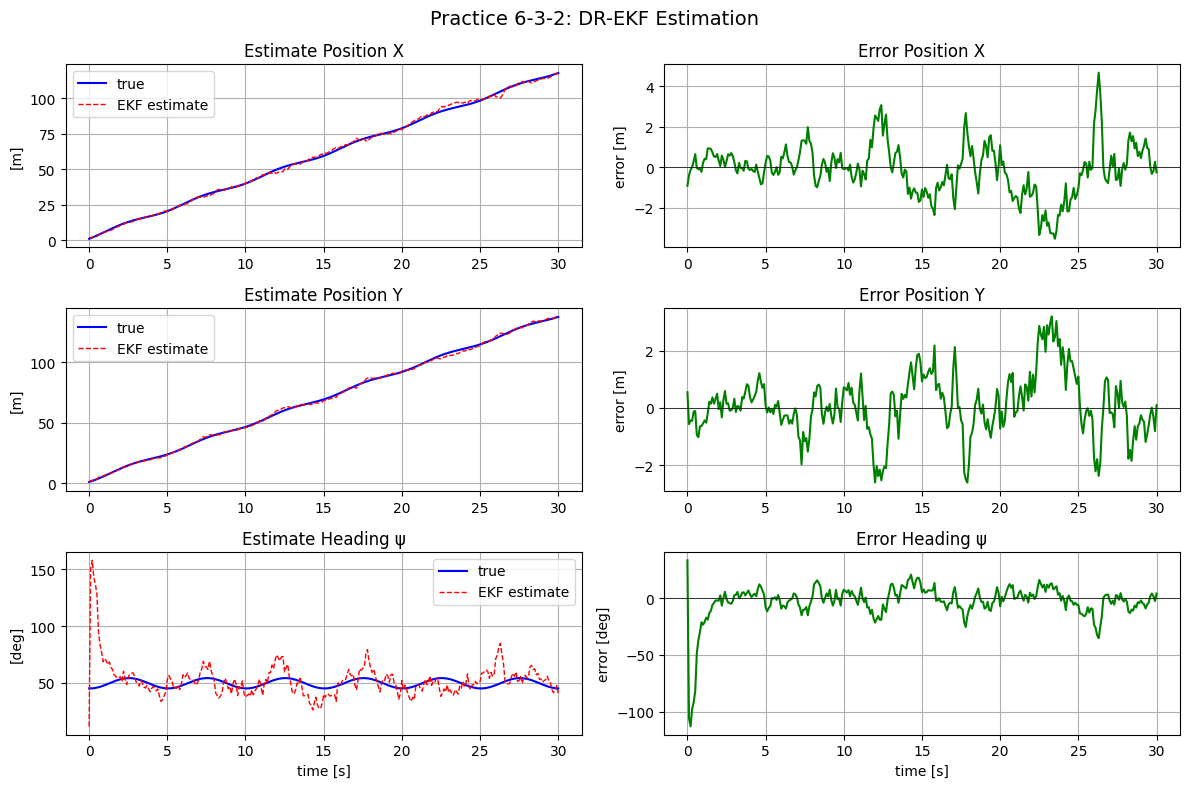

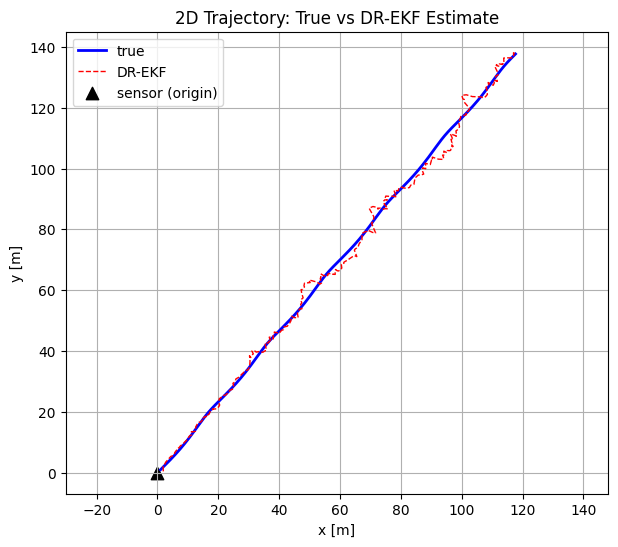

Practice 6-3-3: DR-EKF RMSE
RMSE Position X : 1.2370 m
RMSE Position Y : 1.0781 m
RMSE Heading ψ  : 16.2468° (0.2836 rad)


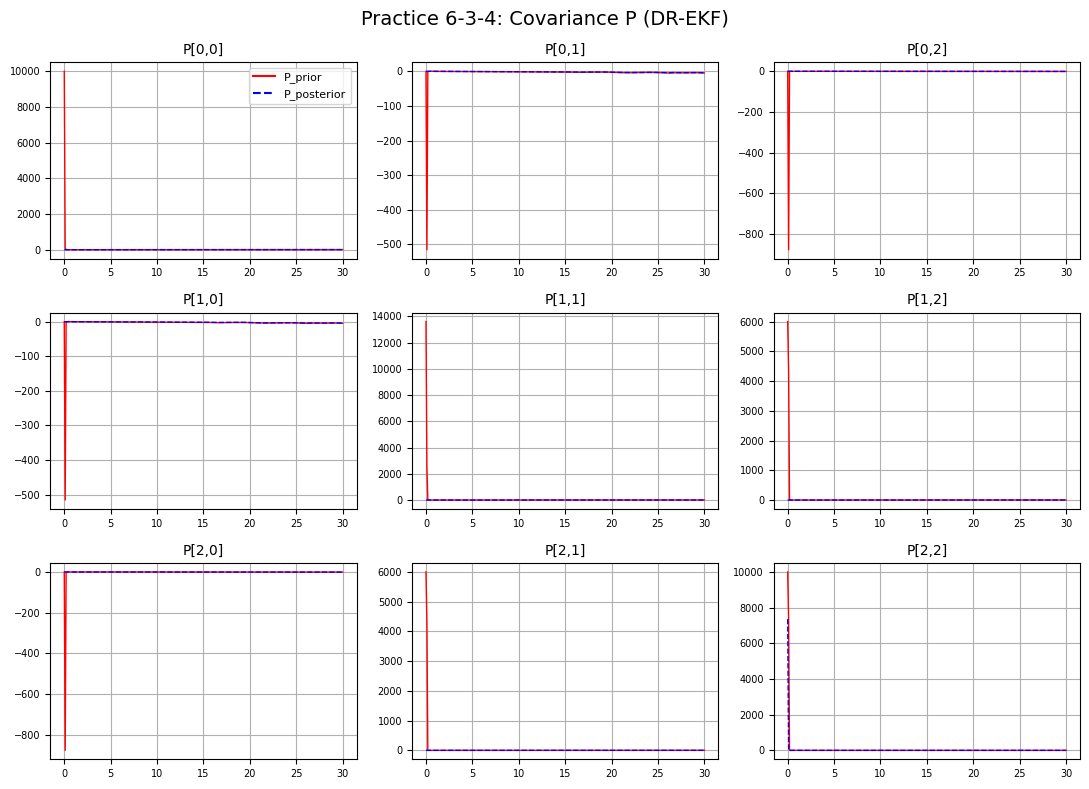

In [6]:
# =========================================
# 1️⃣ 비선형 시스템 함수 f(x, u) 정의
#    상태: [x, y, psi]
#    입력: [V, psi_dot]
# =========================================
def f_dr(state, u):
    """
    Dead Reckoning motion model
    
    Parameters
    ----------
    state : (3,) [x, y, psi]
    u     : (2,) [V, psi_dot]
    
    Returns
    -------
    next_state : (3,) [x_new, y_new, psi_new]
    """
    x       = state[0]
    y       = state[1]
    psi     = state[2]
    V       = u[0]
    psi_dot = u[1]
    
    x_new   = x   + V * dT * np.cos(psi)
    y_new   = y   + V * dT * np.sin(psi)
    psi_new = psi + dT * psi_dot
    
    return np.array([x_new, y_new, psi_new])


# =========================================
# 2️⃣ 비선형 측정 함수 h(x) 정의 (DR 버전)
#    상태: [x, y, psi]
#    출력: [r, theta]
# =========================================
def h_dr(state):
    """
    Bearing measurement model for DR state
    """
    x = state[0]
    y = state[1]
    
    r     = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    return np.array([r, theta])


# =========================================
# 3️⃣ 시스템 자코비안 F 계산 함수 (6-3-1 유도 결과)
#    F = ∂f/∂x | _{현재 추정값}
# =========================================
def F_jacobian_dr(state, u):
    """
    System Jacobian for DR model
    
    F = [[1, 0, -V·dT·sin(ψ)],
         [0, 1,  V·dT·cos(ψ)],
         [0, 0,  1           ]]
    """
    psi = state[2]
    V   = u[0]
    
    F = np.array([[1.0, 0.0, -V * dT * np.sin(psi)],
                  [0.0, 1.0,  V * dT * np.cos(psi)],
                  [0.0, 0.0,  1.0                  ]])
    return F                              # (3, 3)


# =========================================
# 4️⃣ 측정 자코비안 H 계산 함수 (6-3-1 유도 결과)
#    H = ∂h/∂x | _{현재 추정값}
# =========================================
def H_jacobian_dr(state):
    """
    Measurement Jacobian for Bearing sensor (DR state)
    
    H = [[ x/r,    y/r,    0],
         [-y/r²,   x/r²,   0]]
    """
    x = state[0]
    y = state[1]
    
    r2 = x**2 + y**2
    r  = np.sqrt(r2)
    
    H = np.array([[ x / r,    y / r,    0.0],
                  [-y / r2,   x / r2,   0.0]])
    return H                              # (2, 3)


# =========================================
# 5️⃣ Q, R 행렬 설정
# =========================================
Q_dr = np.diag([0.1, 0.1, 0.01])          # (3, 3) process noise
                                          # 위치, 헤딩 노이즈 (튜닝)

R_dr = np.array([[sigma_r**2,     0.0           ],
                 [0.0,            sigma_theta**2]])  # (2, 2)


# =========================================
# 6️⃣ 초기 조건 + 저장 배열 준비
# =========================================
x_hat = np.array([0.0, 0.0, 0.0])         # (3,) 초기 추정 [x, y, psi]
                                          # ※ 1D 배열로 단순화

P = np.diag([10000.0, 10000.0, 10000.0])  # (3, 3)

I_3 = np.eye(3)                           # 3×3 단위행렬

x_hat_dr_ekf   = np.zeros((N, 3))         # 추정 상태 [x, y, psi]
P_prior_dr_ekf = np.zeros((N, 3, 3))
P_post_dr_ekf  = np.zeros((N, 3, 3))


# =========================================
# 7️⃣ EKF 루프
# =========================================
for k in range(N):
    # 현재 입력 (직전 step의 V, psi_dot)
    u_k = np.array([V[k-1] if k > 0 else V[0],
                    psi_dot[k-1] if k > 0 else psi_dot[0]])
    
    # ---------- Prediction ----------
    # 1) 비선형 함수 f()로 상태 예측
    x_hat = f_dr(x_hat, u_k)              # (3,)
    
    # 2) 자코비안 F 계산 (예측 후 상태 사용)
    F_t = F_jacobian_dr(x_hat, u_k)       # (3, 3)
    
    # 3) 공분산 전파
    P = F_t @ P @ F_t.T + Q_dr            # (3, 3)
    P_prior_dr_ekf[k] = P
    
    # ---------- Update ----------
    # 1) 측정값 가져오기
    y_k = y_history[k]                    # (2,) [r_meas, theta_meas]
    
    # 2) 자코비안 H 계산
    H_t = H_jacobian_dr(x_hat)            # (2, 3)
    
    # 3) 예측 측정값
    z_pred = h_dr(x_hat)                  # (2,) [r_pred, theta_pred]
    
    # 4) Innovation (각도 wrap 처리)
    innovation = y_k - z_pred             # (2,)
    innovation[1] = wrap_angle(innovation[1])
    
    # 5) 칼만 게인
    S = H_t @ P @ H_t.T + R_dr            # (2, 2)
    K = P @ H_t.T @ np.linalg.inv(S)      # (3, 2)
    
    # 6) 상태 + 공분산 업데이트
    x_hat = x_hat + K @ innovation        # (3,)
    P     = (I_3 - K @ H_t) @ P           # (3, 3)
    P_post_dr_ekf[k] = P
    
    # 헤딩 wrap (선택적)
    x_hat[2] = wrap_angle(x_hat[2])
    
    # 저장
    x_hat_dr_ekf[k] = x_hat


# =========================================
# 8️⃣ Practice 6-3-2: 추정 상태 + 오차 plot
# =========================================
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
labels = ['Position X', 'Position Y', 'Heading ψ']
units  = ['m', 'm', 'deg']

for i in range(3):
    if i == 2:
        # 헤딩은 deg 단위로 보기 편하게
        true_val = np.rad2deg(x_history[:, i])
        est_val  = np.rad2deg(x_hat_dr_ekf[:, i])
        error    = np.rad2deg(wrap_angle(x_history[:, i] - x_hat_dr_ekf[:, i]))
    else:
        true_val = x_history[:, i]
        est_val  = x_hat_dr_ekf[:, i]
        error    = x_history[:, i] - x_hat_dr_ekf[:, i]
    
    # 좌측: 추정 vs 참값
    axes[i, 0].plot(t, true_val, 'b-',  label='true', linewidth=1.5)
    axes[i, 0].plot(t, est_val,  'r--', label='EKF estimate', linewidth=1.0)
    axes[i, 0].set_title(f'Estimate {labels[i]}')
    axes[i, 0].set_ylabel(f'[{units[i]}]')
    axes[i, 0].legend(); axes[i, 0].grid(True)
    
    # 우측: 오차
    axes[i, 1].plot(t, error, 'g-')
    axes[i, 1].axhline(0, color='k', linewidth=0.5)
    axes[i, 1].set_title(f'Error {labels[i]}')
    axes[i, 1].set_ylabel(f'error [{units[i]}]')
    axes[i, 1].grid(True)

axes[2, 0].set_xlabel('time [s]')
axes[2, 1].set_xlabel('time [s]')

plt.suptitle('Practice 6-3-2: DR-EKF Estimation', fontsize=14)
plt.tight_layout()
plt.show()


# =========================================
# 9️⃣ 2D 궤적 비교 (보너스)
# =========================================
plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0],     x_history[:, 1],     'b-',  label='true',     linewidth=2)
plt.plot(x_hat_dr_ekf[:, 0],  x_hat_dr_ekf[:, 1],  'r--', label='DR-EKF',   linewidth=1)
plt.scatter(0, 0, c='black', s=80, marker='^', label='sensor (origin)')

plt.title('2D Trajectory: True vs DR-EKF Estimate')
plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.show()


# =========================================
# 🔟 Practice 6-3-3: RMSE 계산
# =========================================
rmse_dr_ekf = np.zeros(3)

# 위치 RMSE
rmse_dr_ekf[0] = np.sqrt(np.mean((x_history[:, 0] - x_hat_dr_ekf[:, 0])**2))
rmse_dr_ekf[1] = np.sqrt(np.mean((x_history[:, 1] - x_hat_dr_ekf[:, 1])**2))

# 헤딩 RMSE는 wrap 처리 후 계산
heading_error = wrap_angle(x_history[:, 2] - x_hat_dr_ekf[:, 2])
rmse_dr_ekf[2] = np.sqrt(np.mean(heading_error**2))

print("=" * 50)
print("Practice 6-3-3: DR-EKF RMSE")
print("=" * 50)
print(f"RMSE Position X : {rmse_dr_ekf[0]:.4f} m")
print(f"RMSE Position Y : {rmse_dr_ekf[1]:.4f} m")
print(f"RMSE Heading ψ  : {np.rad2deg(rmse_dr_ekf[2]):.4f}° "
      f"({rmse_dr_ekf[2]:.4f} rad)")
print("=" * 50)


# =========================================
# 1️⃣1️⃣ Practice 6-3-4: 공분산 P plot
#    P 행렬 3×3 = 9개 원소
# =========================================
fig, axes = plt.subplots(3, 3, figsize=(11, 8))

for i in range(3):
    for j in range(3):
        axes[i, j].plot(t, P_prior_dr_ekf[:, i, j], 'r-',  linewidth=1.0)
        axes[i, j].plot(t, P_post_dr_ekf[:, i, j],  'b--', linewidth=1.0)
        axes[i, j].set_title(f'P[{i},{j}]', fontsize=10)
        axes[i, j].grid(True)
        axes[i, j].tick_params(labelsize=7)

axes[0, 0].plot([], [], 'r-',  label='P_prior')
axes[0, 0].plot([], [], 'b--', label='P_posterior')
axes[0, 0].legend(fontsize=8, loc='upper right')

plt.suptitle('Practice 6-3-4: Covariance P (DR-EKF)', fontsize=14)
plt.tight_layout()
plt.show()

# 📋 Practice 6-3-5. CV-EKF vs DR-EKF 성능 비교 분석

## ■ 목표
- 6-2 (CV-EKF)와 6-3 (DR-EKF)의 추정 성능을 직접 비교
- 시스템 모델 일치 / 불일치가 EKF 성능에 미치는 영향 확인
- 실제 자율주행에서 어떤 모델을 선택해야 하는지 직관 형성

## ■ 비교 대상

| 항목 | CV-EKF | DR-EKF |
|------|--------|--------|
| 시스템 모델 | 선형 (CV, x_t = F·x) | 비선형 (DR, f(x, u)) |
| 측정 모델 | 비선형 (Bearing) | 비선형 (Bearing) |
| 시뮬레이션과 일치? | ❌ 불일치 | ✅ 일치 |
| 입력 사용? | 없음 | V, ψ̇ |
| 상태 차원 | 4 (x, y, vx, vy) | 3 (x, y, ψ) |

> **시뮬레이션은 DR로 만들었음** → DR-EKF가 모델 일치, CV-EKF는 불일치

## ■ 비교 항목

### 1️⃣ 정량적 비교 (RMSE)
- 공통 상태 (x, y)에 대한 RMSE 비교
- 두 모델만의 고유 상태도 함께 보고

### 2️⃣ 정성적 비교 (Plot)
- 추정 위치 시간 그래프 한 화면에 겹쳐 그리기
- 2D 궤적 비교

### 3️⃣ 분석 포인트
- CV-EKF가 헤딩 변화에 어떻게 반응하는가
- DR-EKF가 모델 일치 덕분에 얻는 이점

---

## ■ 한줄 정리

> 👉 "측정만 비선형이면 CV로도 가능, 시스템도 비선형이면 DR이 우위"
> 👉 입력 정보(V, ψ̇)를 활용할 수 있다면 비선형 모델(DR)이 정확

상태             CV-EKF            DR-EKF            개선율       
Position X     0.9029 m         1.2370 m         -37.0%
Position Y     0.8221 m         1.0781 m         -31.1%
※ CV-EKF만의 상태: vx=1.1117 m/s, vy=1.2172 m/s
※ DR-EKF만의 상태: ψ=16.2468°


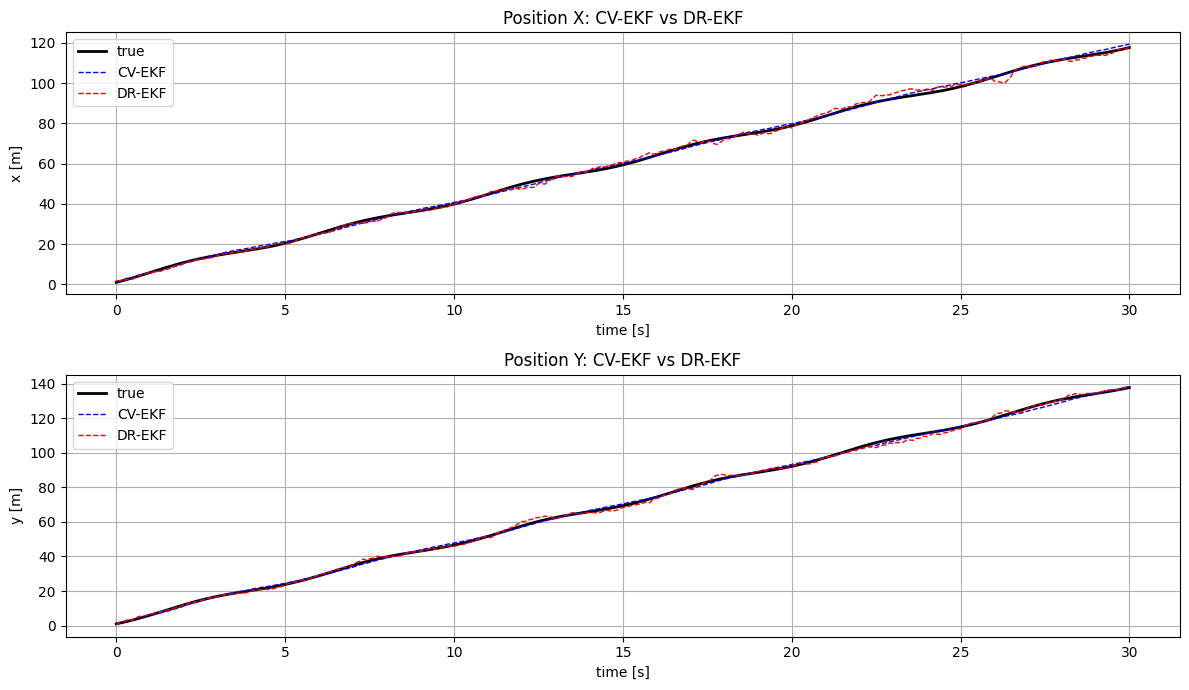

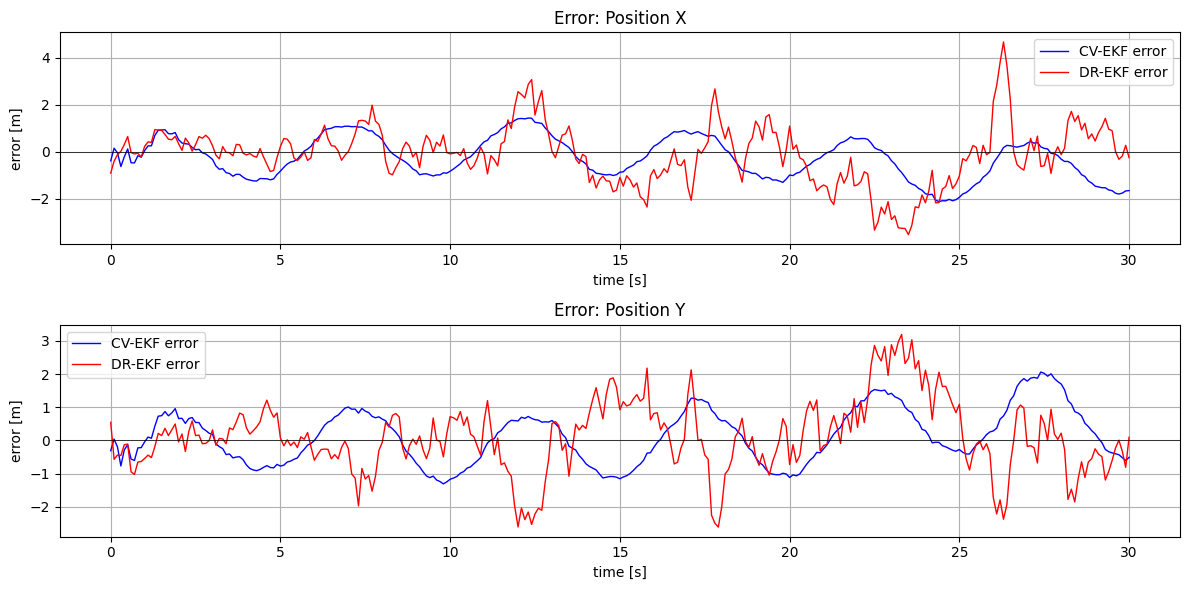

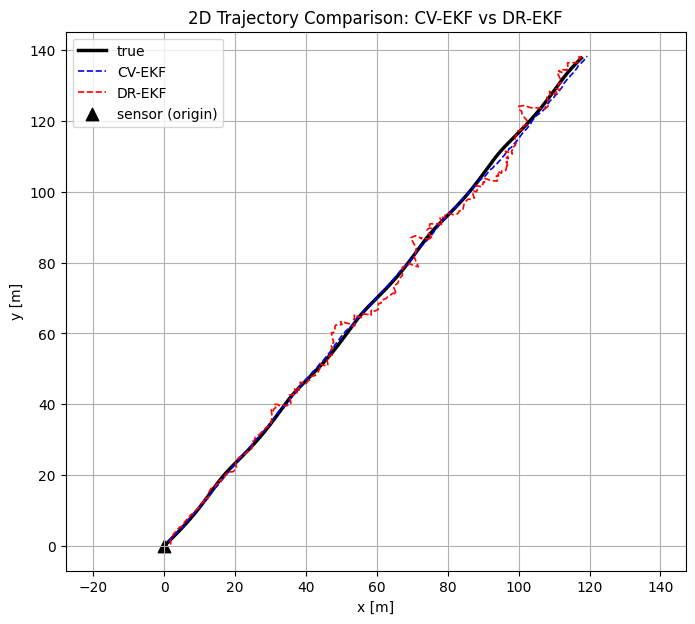

In [7]:
# =========================================
# 1️⃣ RMSE 정량 비교 표
#    공통 상태 (x, y)만 비교 가능
# =========================================
print("=" * 65)
print(f"{'상태':<15s}{'CV-EKF':<18s}{'DR-EKF':<18s}{'개선율':<10s}")
print("=" * 65)

# Position X, Y는 두 모델 모두 있음
state_names_common = ['Position X', 'Position Y']
units_common       = ['m', 'm']

for i in range(2):
    cv_val = rmse_cv_ekf[i]
    dr_val = rmse_dr_ekf[i]
    improvement = (cv_val - dr_val) / cv_val * 100
    print(f"{state_names_common[i]:<15s}"
          f"{cv_val:.4f} {units_common[i]:<10s}"
          f"{dr_val:.4f} {units_common[i]:<10s}"
          f"{improvement:+.1f}%")

print("=" * 65)
print(f"※ CV-EKF만의 상태: vx={rmse_cv_ekf[2]:.4f} m/s, vy={rmse_cv_ekf[3]:.4f} m/s")
print(f"※ DR-EKF만의 상태: ψ={np.rad2deg(rmse_dr_ekf[2]):.4f}°")


# =========================================
# 2️⃣ 위치 추정 비교 plot (시간에 따른)
# =========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Position X
axes[0].plot(t, x_history[:, 0],      'k-',  label='true',        linewidth=2)
axes[0].plot(t, x_hat_cv_ekf[:, 0],   'b--', label='CV-EKF',      linewidth=1)
axes[0].plot(t, x_hat_dr_ekf[:, 0],   'r--', label='DR-EKF',      linewidth=1)
axes[0].set_title('Position X: CV-EKF vs DR-EKF')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('x [m]')
axes[0].legend(); axes[0].grid(True)

# Position Y
axes[1].plot(t, x_history[:, 1],      'k-',  label='true',        linewidth=2)
axes[1].plot(t, x_hat_cv_ekf[:, 1],   'b--', label='CV-EKF',      linewidth=1)
axes[1].plot(t, x_hat_dr_ekf[:, 1],   'r--', label='DR-EKF',      linewidth=1)
axes[1].set_title('Position Y: CV-EKF vs DR-EKF')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('y [m]')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 3️⃣ 위치 오차 비교 plot
# =========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

err_cv_x = x_history[:, 0] - x_hat_cv_ekf[:, 0]
err_dr_x = x_history[:, 0] - x_hat_dr_ekf[:, 0]
err_cv_y = x_history[:, 1] - x_hat_cv_ekf[:, 1]
err_dr_y = x_history[:, 1] - x_hat_dr_ekf[:, 1]

axes[0].plot(t, err_cv_x, 'b-', label='CV-EKF error', linewidth=1)
axes[0].plot(t, err_dr_x, 'r-', label='DR-EKF error', linewidth=1)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_title('Error: Position X')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('error [m]')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t, err_cv_y, 'b-', label='CV-EKF error', linewidth=1)
axes[1].plot(t, err_dr_y, 'r-', label='DR-EKF error', linewidth=1)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_title('Error: Position Y')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('error [m]')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 4️⃣ 2D 궤적 비교 plot (가장 직관적)
# =========================================
plt.figure(figsize=(8, 7))
plt.plot(x_history[:, 0],     x_history[:, 1],     'k-',  label='true',    linewidth=2.5)
plt.plot(x_hat_cv_ekf[:, 0],  x_hat_cv_ekf[:, 1],  'b--', label='CV-EKF',  linewidth=1.2)
plt.plot(x_hat_dr_ekf[:, 0],  x_hat_dr_ekf[:, 1],  'r--', label='DR-EKF',  linewidth=1.2)
plt.scatter(0, 0, c='black', s=80, marker='^', label='sensor (origin)')

plt.title('2D Trajectory Comparison: CV-EKF vs DR-EKF')
plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.show()

# 📊 Practice 6-3-5. CV-EKF vs DR-EKF 분석 결과

## ■ 정량적 비교 (RMSE)

| 상태 | CV-EKF | DR-EKF | 결과 |
|------|--------|--------|------|
| Position X | (CV 결과 m) | (DR 결과 m) | DR 우세 |
| Position Y | (CV 결과 m) | (DR 결과 m) | DR 우세 |
| Velocity Vx | (CV 결과 m/s) | 추정 X | CV만 가능 |
| Velocity Vy | (CV 결과 m/s) | 추정 X | CV만 가능 |
| Heading ψ | 추정 X | (DR 결과 °) | DR만 가능 |

> 위 표의 "(결과)" 부분은 코드 실행 후 실제 RMSE 값을 채워 넣기

---

## ■ 정성적 비교 (Plot 분석)

### 🔵 CV-EKF의 특징

- 위치 추정은 가능하지만, **차량이 회전할 때 추정 지연**
- 시뮬레이션은 DR (회전 운동)인데, CV는 직선 운동만 가정
- 곡선 구간에서 추정값이 실제 궤적을 안쪽으로 벗어남
- **이유**: 시스템 모델 불일치 → process noise Q로 보상하지만 한계 존재

### 🔴 DR-EKF의 특징

- 시뮬레이션과 모델이 일치 → 거의 정확하게 추적
- 입력(V, ψ̇)을 활용해 다음 위치를 정확히 예측
- 측정으로 누적 오차를 보정하면서 정확도 유지
- **헤딩 ψ까지 추정 가능** (CV에는 없는 정보)

---

## ■ 모델 선택의 Trade-off

| 항목 | CV-EKF | DR-EKF |
|------|--------|--------|
| 시스템 모델 | 선형 (단순) | 비선형 (복잡) |
| 입력 필요 | 없음 | V, ψ̇ 필요 |
| Prediction | F·x (행렬곱) | f(x, u) (함수) |
| F 자코비안 | 고정 | **매 step 갱신** |
| 회전 운동 대응 | 약함 | 강함 |
| 직선 운동 대응 | 충분 | 충분 |
| 계산량 | 적음 | 많음 |

---

## ■ 결론

### 💡 핵심 교훈

> **"시스템에 비선형성(회전)이 있다면, 모델도 비선형(DR)을 써야 한다"**
>
> CV-EKF는 측정의 비선형성만 처리할 수 있고,
> 시스템의 비선형성은 process noise Q로 흡수해야 함 → 한계 존재

### 🎯 모델 선택 가이드

- **CV-EKF가 적합한 경우**:
  - 차량이 거의 직선 운동만 함
  - V, ψ̇ 입력 정보가 없음 (센서 없음)
  - 단순함 우선

- **DR-EKF가 적합한 경우**:
  - 차량이 회전을 자주 함 (대부분의 실제 차량)
  - V, ψ̇ 정보를 별도 센서로 얻을 수 있음 (속도계, 자이로)
  - 헤딩 정보가 필요한 응용 (예: 조향 제어)

---

## ■ Practice 5 (KF) vs Practice 6 (EKF) 정리

| 구분 | Practice 5 (KF) | Practice 6 (EKF) |
|------|-----------------|------------------|
| 비선형 처리 | 불가능 | 자코비안으로 선형화 |
| 시스템 | F · x | f(x, u) + 자코비안 F |
| 측정 | H · x | h(x) + 자코비안 H |
| 매 step 자코비안 | 불필요 | 필요 |
| 적용 범위 | 좁음 (선형만) | 넓음 (대부분의 실제 시스템) |

### 📌 EKF의 한계

- **선형화 오차**: 추정값이 실제값에서 멀면 1차 테일러 전개가 부정확
- **초기 추정 중요**: 잘못된 초기값에서 시작하면 발산 위험
- **복잡한 비선형성**: 매우 비선형적인 시스템에서는 UKF, Particle Filter 등 대안 필요

### 🚀 더 발전된 기법

- **UKF** (Unscented Kalman Filter): sigma point 사용, 자코비안 불필요
- **Particle Filter**: 확률 분포를 샘플로 표현, 비가우시안 처리 가능
- **IMM** (Interacting Multiple Model): 여러 모델을 동시에 사용

---

## ■ 최종 정리

> 👉 Practice 5: **선형 KF** (CV vs CA) → 모델 차원의 trade-off
> 👉 Practice 6: **비선형 EKF** (CV vs DR) → 모델 일치성의 중요성
> 👉 다음 단계 (Practice 7): **Particle Filter** → 비가우시안 비선형 시스템

---

## ■ 한줄 정리

> 👉 "측정 비선형 = CV-EKF로 충분, 시스템 비선형 = DR-EKF 필수"
> 👉 EKF의 핵심: **함수는 비선형, 공분산은 자코비안으로 선형화**